# Chapter 4: Experiments, Results and Discussion — Final M.Sc Analysis Notebook

This notebook provides the complete quantitative analysis required for Chapter 4 of the dissertation.

It is aligned directly with the three research questions:

- **RQ1:** On the selected PMLB classification datasets, how does an MLP compare with Logistic Regression, Random Forest and XGBoost in terms of balanced accuracy?
- **RQ2:** Are MLPs more likely to outperform the baseline models on datasets that are difficult for Logistic Regression, Random Forest and XGBoost?
- **RQ3:** Which dataset attributes are associated with cases where the MLP outperforms or competes with the tree-based ensemble models?

### Study-specific analytical rules

1. The **69-dataset common analytical sample** is used for the principal four-model comparisons.
2. **Balanced accuracy** is the primary performance endpoint.
3. **Bottom datasets are the primary operational representation of difficult datasets for RQ2**, because they were selected from poor baseline-model performance before the MLP results were interpreted.
4. The continuous baseline-difficulty score is retained only as a **secondary robustness analysis**.
5. MLP competitiveness is measured as:
   \[
   \Delta_{MLP,i}=BA_{MLP,i}-\max(BA_{LR,i},BA_{RF,i},BA_{XGB,i})
   \]
6. RQ3 analyses dataset meta-features against **MLP competitiveness (the MLP margin)** rather than absolute MLP balanced accuracy.
7. Statistical non-significance is **not** interpreted as statistical equivalence.
8. Feature importance is interpreted only after the exploratory meta-model has been evaluated out-of-sample.

All tables and figures are exported to the `tables/` and `figures/` directories.

---
# Part 1 — Data Loading, Preprocessing & Exploratory Data Analysis
## Section 4.1: Experimental Setup

In [2]:
import subprocess, sys

required_packages = [
    "pandas", "numpy", "matplotlib", "seaborn", "scipy",
    "scikit-posthocs", "scikit-learn", "statsmodels",
    "openpyxl", "tabulate"
]

for pkg in required_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All dependencies are ready.")

All dependencies are ready.


In [3]:
import warnings, os, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare, shapiro, mannwhitneyu
import scikit_posthocs as sp

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate, KFold
from sklearn.inspection import permutation_importance
from statsmodels.stats.multitest import multipletests
from tabulate import tabulate

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

MODEL_COLORS = {"MLP": "#2196F3", "RF": "#4CAF50", "XGB": "#FF9800", "LR": "#9C27B0"}
MODEL_LABELS = {
    "MLP_BA": "MLP",
    "RF_BA": "Random Forest",
    "XGB_BA": "XGBoost",
    "LR_BA": "Logistic Regression",
}
MODELS = ["MLP_BA", "RF_BA", "XGB_BA", "LR_BA"]
MODEL_SHORT = ["MLP", "RF", "XGB", "LR"]

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Matplotlib {matplotlib.__version__}")

NumPy 1.26.4 | Pandas 3.0.3 | Matplotlib 3.10.9


## 4.1.1 Loading the Experimental Data

In [4]:
required_files = {
    "Final_Performance_Table.csv": "Final four-model performance table",
    "Datasets_Characteristics.csv": "Dataset meta-features",
    "bottom_datasets_mlp_best.csv": "Bottom-group MLP best configurations",
    "top_datasets_mlp.csv": "Top-group MLP best configurations",
    "Master_Performance_Table.csv": "Master performance table",
}

missing_files = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError(
        "Missing required source files: " + ", ".join(missing_files) +
        ". Place them in the same directory as this notebook."
    )

df_perf = pd.read_csv("Final_Performance_Table.csv")
df_char = pd.read_csv("Datasets_Characteristics.csv")
df_bot = pd.read_csv("bottom_datasets_mlp_best.csv")
df_top = pd.read_csv("top_datasets_mlp.csv")
df_mast = pd.read_csv("Master_Performance_Table.csv")

# Standardise dataset key
for frame_name, frame in [("df_char", df_char), ("df_bot", df_bot), ("df_top", df_top), ("df_mast", df_mast)]:
    if "Dataset" in frame.columns and "Datasets" not in frame.columns:
        frame.rename(columns={"Dataset": "Datasets"}, inplace=True)

required_perf_cols = {"Datasets", "Dataset_Type", "MLP_BA", "RF_BA", "XGB_BA", "LR_BA",
                      "Rows", "Features", "Classes", "Imbalance"}
missing_cols = required_perf_cols - set(df_perf.columns)
if missing_cols:
    raise ValueError(f"Final_Performance_Table.csv is missing required columns: {sorted(missing_cols)}")

df_perf["Dataset_Type"] = df_perf["Dataset_Type"].astype(str).str.strip().str.lower()

print("=" * 70)
for name, d in [
    ("Final_Performance_Table", df_perf),
    ("Datasets_Characteristics", df_char),
    ("bottom_datasets_mlp_best", df_bot),
    ("top_datasets_mlp", df_top),
    ("Master_Performance_Table", df_mast),
]:
    print(f"{name:30s}: {d.shape[0]:>4} rows × {d.shape[1]} columns")
print("=" * 70)

Final_Performance_Table       :   69 rows × 10 columns
Datasets_Characteristics      :   69 rows × 11 columns
bottom_datasets_mlp_best      :   28 rows × 6 columns
top_datasets_mlp              :   41 rows × 7 columns
Master_Performance_Table      :   69 rows × 6 columns


## 4.1.2 Data Quality Checks

In [5]:
print("=== Data Quality Audit ===")
print(f"Performance-table duplicate rows: {df_perf.duplicated().sum()}")
print(f"Duplicate dataset IDs: {df_perf['Datasets'].duplicated().sum()}")
print("\nDataset_Type distribution:")
print(df_perf["Dataset_Type"].value_counts(dropna=False))

print("\nMissing values in model balanced-accuracy columns:")
print(df_perf[MODELS].isna().sum())

for col in MODELS:
    nonfinite = (~np.isfinite(pd.to_numeric(df_perf[col], errors="coerce"))).sum()
    out_of_range = ((df_perf[col] < 0) | (df_perf[col] > 1)).sum()
    print(f"{col}: non-finite={nonfinite}, outside [0,1]={out_of_range}")

if df_perf["Datasets"].duplicated().any():
    raise ValueError("Duplicate dataset identifiers found in Final_Performance_Table.csv.")

if not set(df_perf["Dataset_Type"].dropna().unique()).issubset({"top", "bottom"}):
    raise ValueError("Dataset_Type must contain only 'top' and 'bottom' labels for the main analysis.")

=== Data Quality Audit ===
Performance-table duplicate rows: 0
Duplicate dataset IDs: 0

Dataset_Type distribution:
Dataset_Type
top       41
bottom    28
Name: count, dtype: int64

Missing values in model balanced-accuracy columns:
MLP_BA    0
RF_BA     0
XGB_BA    0
LR_BA     0
dtype: int64
MLP_BA: non-finite=0, outside [0,1]=0
RF_BA: non-finite=0, outside [0,1]=0
XGB_BA: non-finite=0, outside [0,1]=0
LR_BA: non-finite=0, outside [0,1]=0


In [6]:
merge_cols = [
    "Datasets",
    "Missing_Values_Count",
    "Missing_Values_Ratio",
    "Numeric_Features",
    "Categorical_Features",
    "Feature_Type",
]
available_merge_cols = [c for c in merge_cols if c in df_char.columns]

df = df_perf.merge(
    df_char[available_merge_cols].drop_duplicates("Datasets"),
    on="Datasets",
    how="left",
)

# Core comparative quantities
df["Best_Baseline"] = df[["RF_BA", "XGB_BA", "LR_BA"]].max(axis=1)
df["MLP_vs_Best"] = df["MLP_BA"] - df["Best_Baseline"]
df["Baseline_Difficulty"] = 1.0 - df["Best_Baseline"]

# Formal average ranks: rank 1 = best. Do not coerce tied average ranks to integers.
rank_df_full = df[MODELS].rank(axis=1, ascending=False, method="average")
df["MLP_Rank"] = rank_df_full["MLP_BA"]

# Joint winner indicator for descriptive first-place counts
row_max = df[MODELS].max(axis=1)
df["MLP_Wins"] = np.isclose(df["MLP_BA"], row_max).astype(int)

# Useful meta-features
df["log_Rows"] = np.log10(df["Rows"].replace(0, np.nan))
df["log_Features"] = np.log10(df["Features"].replace(0, np.nan))
df["Feat_Row_Ratio"] = df["Features"] / df["Rows"].replace(0, np.nan)

df_top_group = df[df["Dataset_Type"].eq("top")].copy()
df_bot_group = df[df["Dataset_Type"].eq("bottom")].copy()
df_complete = df.dropna(subset=MODELS).copy()

print(f"Merged analytical frame: {len(df)} datasets × {df.shape[1]} columns")
print(f"Top group: {len(df_top_group)}")
print(f"Bottom group: {len(df_bot_group)}")
print(f"Complete four-model cases: {len(df_complete)}")

if len(df_complete) != len(df):
    print("WARNING: Some datasets lack complete four-model performance values. "
          "Inferential four-model tests will use complete cases only.")

Merged analytical frame: 69 datasets × 23 columns
Top group: 41
Bottom group: 28
Complete four-model cases: 69


## 4.2 Descriptive Statistics
### 4.2.1 Overall Balanced Accuracy Summary (Table 4.1)

In [7]:
# ── Table 4.1 — Descriptive statistics ────────────────────────────────────────
desc_rows = []
for col, label in MODEL_LABELS.items():
    s = df[col]
    desc_rows.append({
        "Model"  : label,
        "Mean BA": round(s.mean(),4), "Std": round(s.std(),4),
        "Min"    : round(s.min(),4),  "Q1": round(s.quantile(0.25),4),
        "Median" : round(s.median(),4),"Q3": round(s.quantile(0.75),4),
        "Max"    : round(s.max(),4),
    })
desc_df = pd.DataFrame(desc_rows).set_index("Model")
desc_df.to_csv("tables/Table_4_1_Descriptive_Statistics.csv")
print("Table 4.1 — Descriptive Statistics (All 69 Datasets)")
print(tabulate(desc_df, headers="keys", tablefmt="github"))

Table 4.1 — Descriptive Statistics (All 69 Datasets)
| Model               |   Mean BA |    Std |    Min |     Q1 |   Median |     Q3 |   Max |
|---------------------|-----------|--------|--------|--------|----------|--------|-------|
| MLP                 |    0.799  | 0.1894 | 0.2337 | 0.6346 |   0.868  | 0.97   |     1 |
| Random Forest       |    0.7986 | 0.2002 | 0.475  | 0.5718 |   0.8973 | 0.9773 |     1 |
| XGBoost             |    0.6611 | 0.17   | 0.4633 | 0.5198 |   0.5759 | 0.7852 |     1 |
| Logistic Regression |    0.7543 | 0.1814 | 0.4781 | 0.572  |   0.7814 | 0.9259 |     1 |


In [8]:
# ── Descriptive stats by group ─────────────────────────────────────────────────
for gname, gdf in [("TOP (n=41)", df_top_group), ("BOTTOM (n=28)", df_bot_group)]:
    rows = []
    for col, label in MODEL_LABELS.items():
        s = gdf[col]
        rows.append({"Model":label, "Mean":round(s.mean(),4),
                     "Std":round(s.std(),4), "Median":round(s.median(),4),
                     "Min":round(s.min(),4), "Max":round(s.max(),4)})
    print(f"\n=== {gname} ===")
    print(tabulate(pd.DataFrame(rows), headers="keys", tablefmt="github", showindex=False))


=== TOP (n=41) ===
| Model               |   Mean |    Std |   Median |    Min |   Max |
|---------------------|--------|--------|----------|--------|-------|
| MLP                 | 0.9366 | 0.0722 |   0.965  | 0.7202 |     1 |
| Random Forest       | 0.9553 | 0.0473 |   0.9711 | 0.816  |     1 |
| XGBoost             | 0.7581 | 0.1577 |   0.7633 | 0.5078 |     1 |
| Logistic Regression | 0.8793 | 0.1053 |   0.9    | 0.6094 |     1 |

=== BOTTOM (n=28) ===
| Model               |   Mean |    Std |   Median |    Min |    Max |
|---------------------|--------|--------|----------|--------|--------|
| MLP                 | 0.5975 | 0.1084 |   0.6246 | 0.2337 | 0.7602 |
| Random Forest       | 0.569  | 0.075  |   0.5543 | 0.475  | 0.7535 |
| XGBoost             | 0.519  | 0.0264 |   0.5163 | 0.4633 | 0.57   |
| Logistic Regression | 0.5712 | 0.0891 |   0.5492 | 0.4781 | 0.8443 |


### 4.2.2 Dataset Characteristics Summary (Table 4.2)

In [48]:
# ── Table 4.2 — Dataset characteristics ──────────────────────────────────────
char_cols = ["Rows","Features","Classes","Imbalance",
             "Missing_Values_Ratio","Numeric_Features","Categorical_Features"]
char_desc = df[char_cols].describe().T.round(3)
char_desc.to_csv("tables/Table_4_2_Dataset_Characteristics.csv")
print("Dataset Characteristics")
print(tabulate(char_desc, headers="keys", tablefmt="github"))
print("\nFeature type distribution:")
print(df["Feature_Type"].value_counts())
print("\nDatasets with missing values:", (df["Missing_Values_Count"] > 0).sum())

Dataset Characteristics
|                      |   count |     mean |      std |   min |   25% |      50% |      75% |       max |
|----------------------|---------|----------|----------|-------|-------|----------|----------|-----------|
| Rows                 |      69 | 3494.03  | 8817.7   |    42 |   264 | 1212     | 3771     | 67557     |
| Features             |      69 |   45.638 |  123.941 |     2 |     6 |   20     |   40     |  1000     |
| Classes              |      69 |    3.725 |    3.303 |     2 |     2 |    2     |    3     |    18     |
| Imbalance            |      69 |    0.087 |    0.175 |     0 |     0 |    0.001 |    0.063 |     0.698 |
| Missing_Values_Ratio |      69 |    0     |    0     |     0 |     0 |    0     |    0     |     0     |
| Numeric_Features     |      69 |   45.638 |  123.941 |     2 |     6 |   20     |   40     |  1000     |
| Categorical_Features |      69 |    0     |    0     |     0 |     0 |    0     |    0     |     0     |

Feature type

### 4.2.3 Exploratory Visualisations

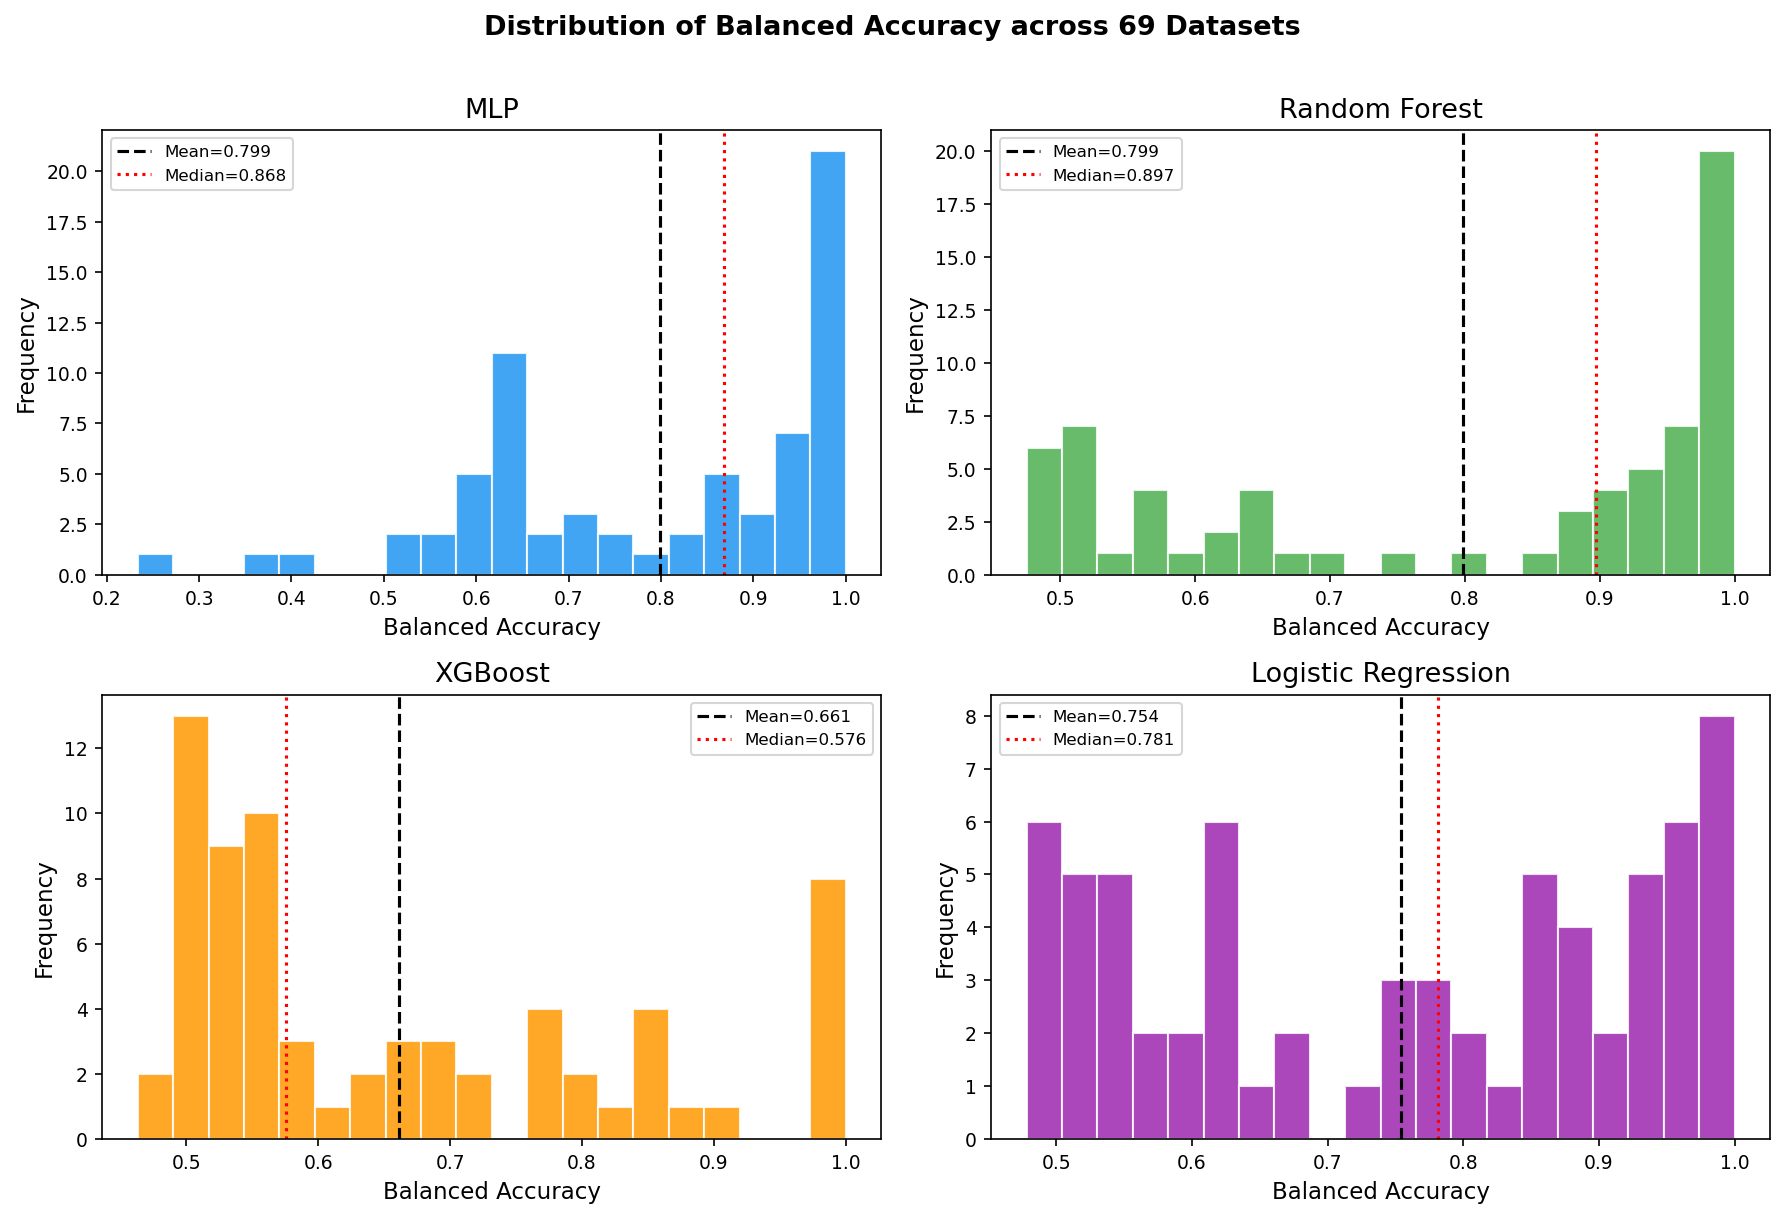

Saved → figures/Fig4_1_BA_Distributions.png


In [49]:
# ── Figure 4.1 — BA distributions (histograms) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, label) in zip(axes.flatten(), MODEL_LABELS.items()):
    color_key = col.replace("_BA", "")
    ax.hist(df[col], bins=20, color=MODEL_COLORS[color_key], edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(),   color="black", lw=1.5, ls="--",
               label=f"Mean={df[col].mean():.3f}")
    ax.axvline(df[col].median(), color="red",   lw=1.5, ls=":",
               label=f"Median={df[col].median():.3f}")
    ax.set_title(label); ax.set_xlabel("Balanced Accuracy"); ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
plt.suptitle("Distribution of Balanced Accuracy across 69 Datasets",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/Fig4_1_BA_Distributions.png"); plt.show()
print("Saved → figures/Fig4_1_BA_Distributions.png")

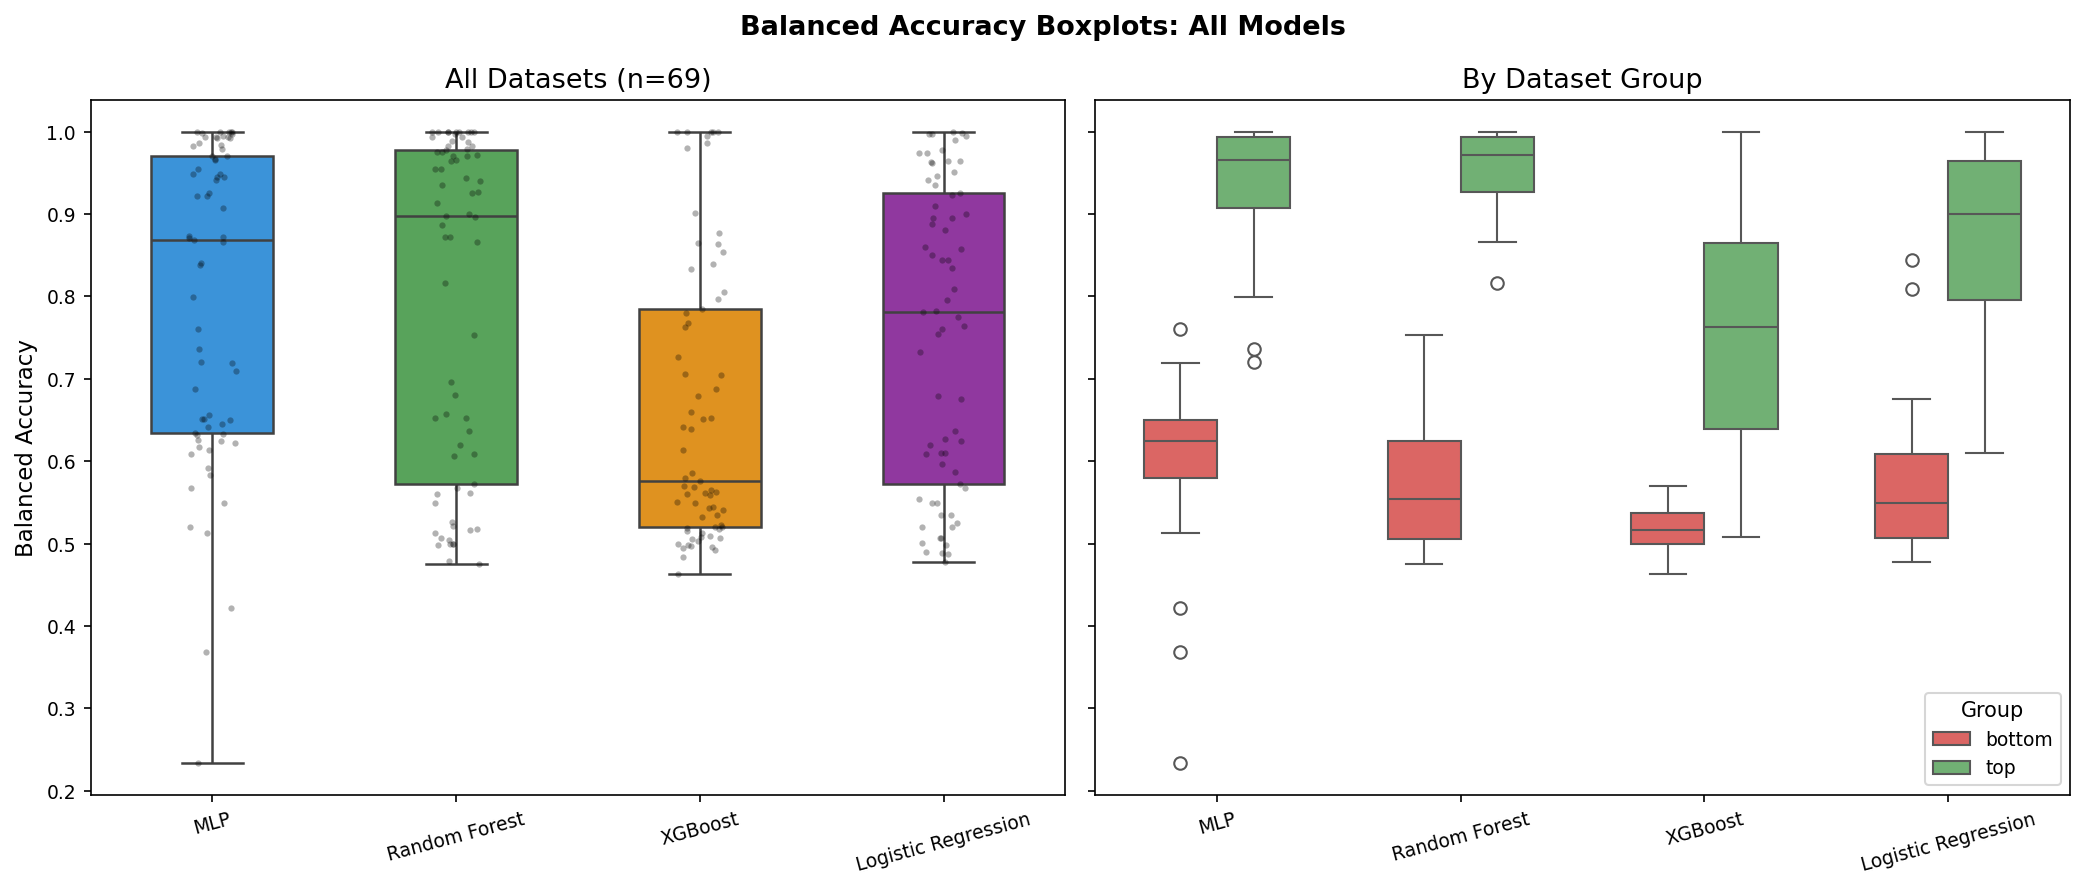

In [50]:
# ── Figure 4.2 — Boxplots by model and group ──────────────────────────────────
ba_long = df.melt(id_vars=["Datasets","Dataset_Type"], value_vars=MODELS,
                   var_name="Model", value_name="Balanced_Accuracy")
ba_long["Model"] = ba_long["Model"].map(MODEL_LABELS)
col_order = list(MODEL_LABELS.values())
pal = [MODEL_COLORS["MLP"], MODEL_COLORS["RF"], MODEL_COLORS["XGB"], MODEL_COLORS["LR"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.boxplot(data=ba_long, x="Model", y="Balanced_Accuracy",
            order=col_order, palette=pal, ax=axes[0], width=0.5, linewidth=1.2)
sns.stripplot(data=ba_long, x="Model", y="Balanced_Accuracy",
              order=col_order, color="black", alpha=0.3, size=3, jitter=True, ax=axes[0])
axes[0].set_title("All Datasets (n=69)"); axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylabel("Balanced Accuracy"); axes[0].set_xlabel("")

sns.boxplot(data=ba_long, x="Model", y="Balanced_Accuracy",
            order=col_order, hue="Dataset_Type",
            palette={"top":"#66BB6A","bottom":"#EF5350"},
            ax=axes[1], width=0.6)
axes[1].set_title("By Dataset Group"); axes[1].tick_params(axis="x", rotation=15)
axes[1].set_ylabel(""); axes[1].set_xlabel("")
axes[1].legend(title="Group")

plt.suptitle("Balanced Accuracy Boxplots: All Models",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_2_Boxplots_All.png"); plt.show()

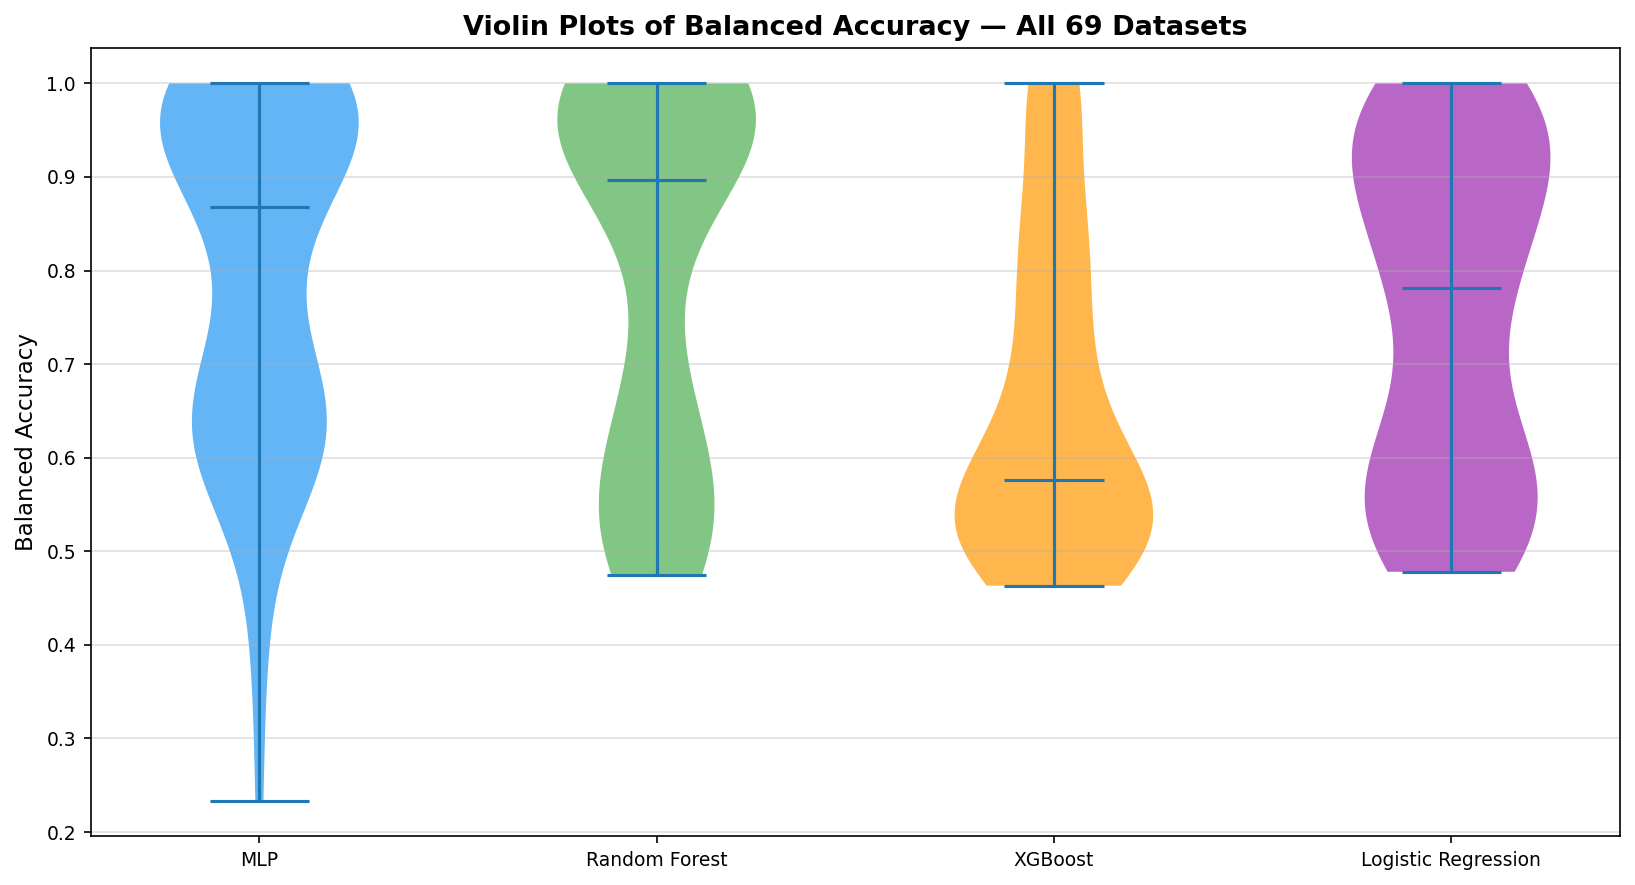

In [51]:
# ── Figure 4.3 — Violin plots ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
parts = ax.violinplot([df[m] for m in MODELS], positions=range(len(MODELS)),
                       showmedians=True, showextrema=True)
colors_v = [MODEL_COLORS["MLP"], MODEL_COLORS["RF"], MODEL_COLORS["XGB"], MODEL_COLORS["LR"]]
for pc, col in zip(parts["bodies"], colors_v):
    pc.set_facecolor(col); pc.set_alpha(0.7)
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS])
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Violin Plots of Balanced Accuracy — All 69 Datasets",
             fontweight="bold")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("figures/Fig4_3_Violin_Plots.png"); plt.show()

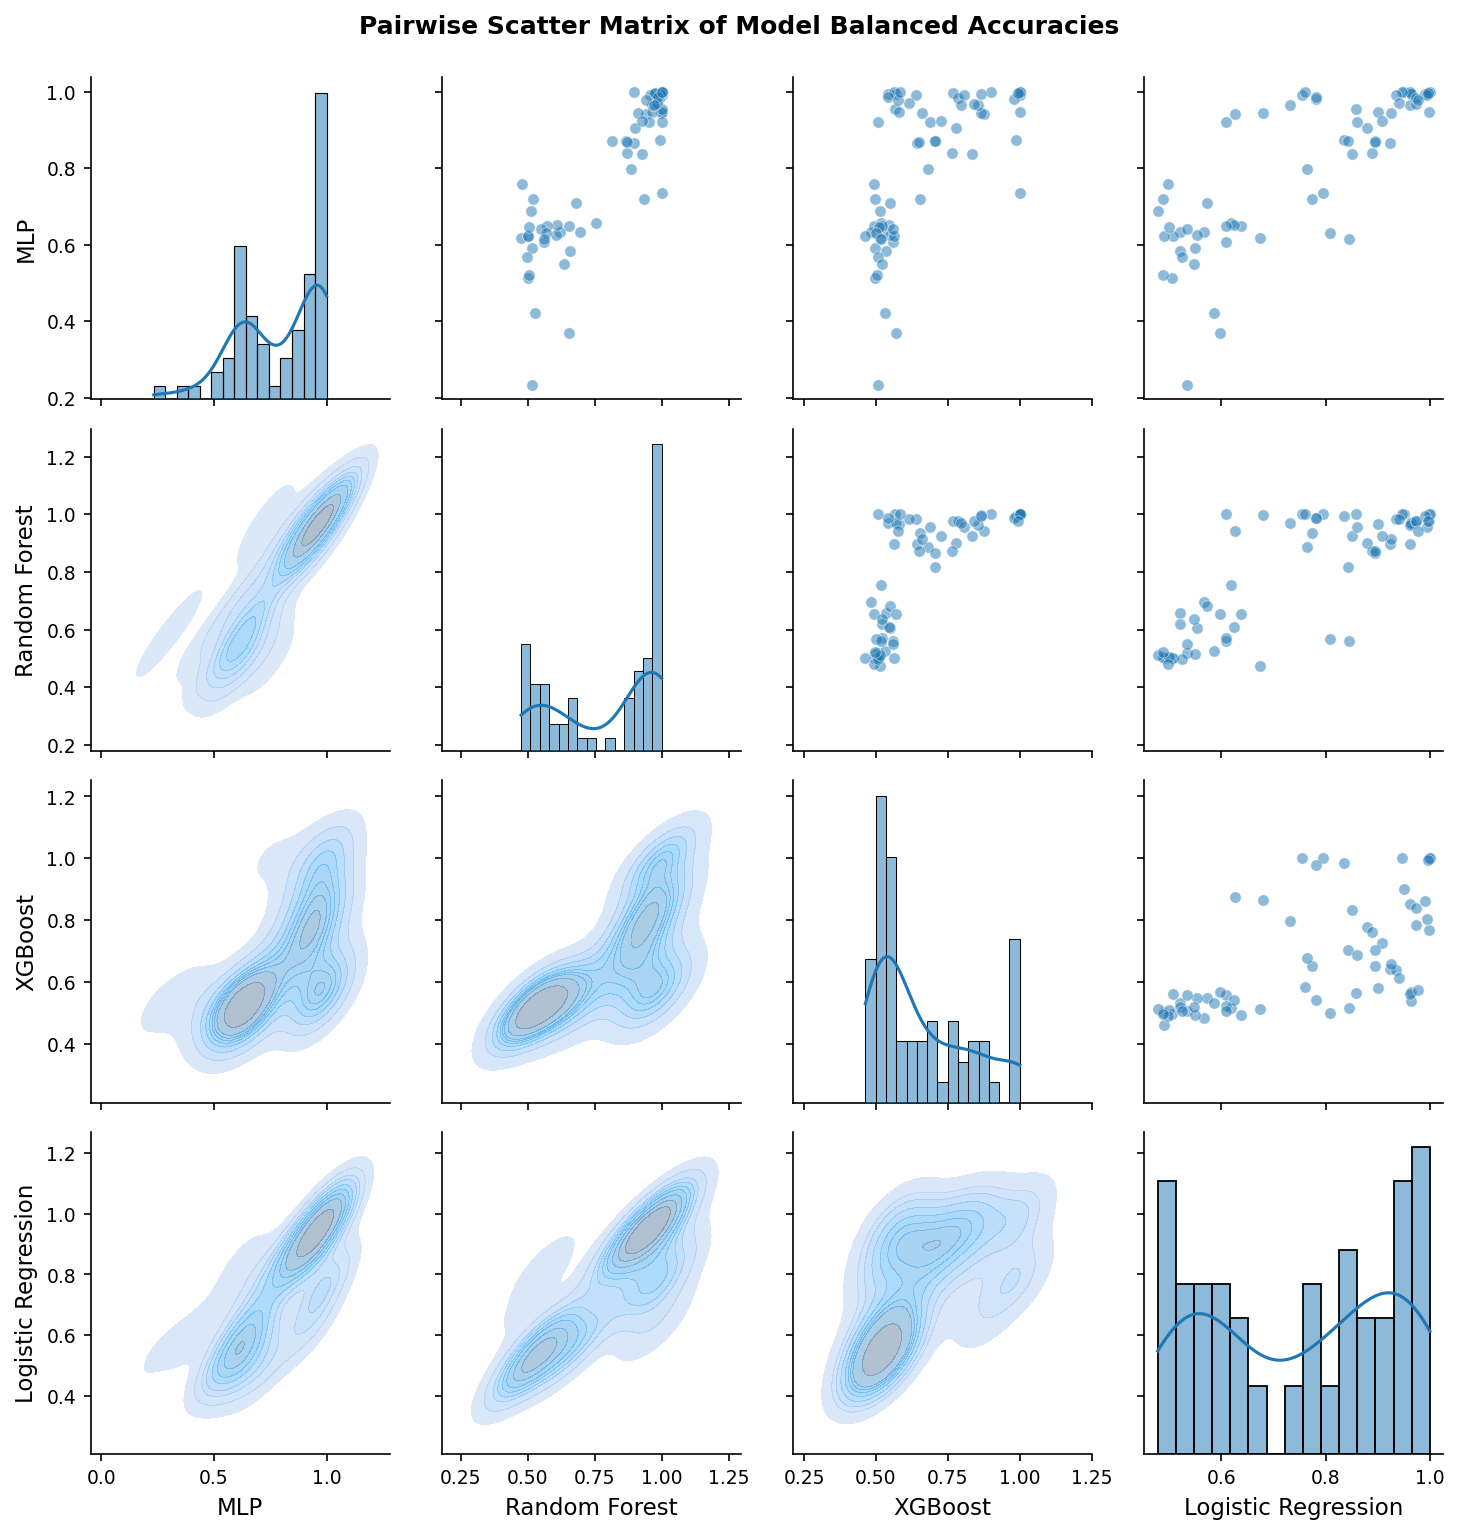

In [52]:
# ── Figure 4.4 — Pairwise scatter matrix ──────────────────────────────────────
perf_only = df[MODELS].rename(columns=MODEL_LABELS)
g = sns.PairGrid(perf_only, diag_sharey=False)
g.map_upper(sns.scatterplot, alpha=0.5, s=30)
g.map_lower(sns.kdeplot, fill=True, alpha=0.4)
g.map_diag(sns.histplot, kde=True, bins=15)
g.figure.suptitle("Pairwise Scatter Matrix of Model Balanced Accuracies",
                   y=1.02, fontweight="bold")
g.figure.savefig("figures/Fig4_4_Scatter_Matrix.png"); plt.show()

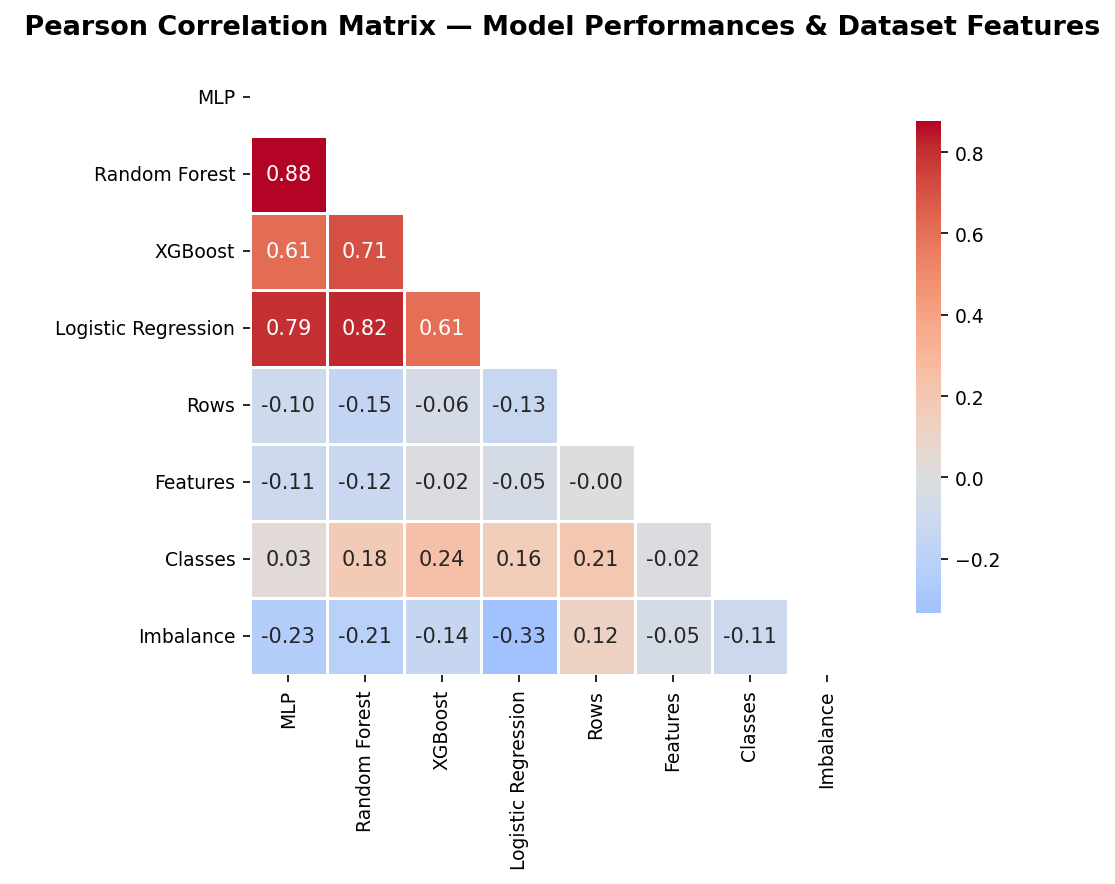

In [53]:
# ── Figure 4.5 — Correlation heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr_cols = ["MLP_BA","RF_BA","XGB_BA","LR_BA","Rows","Features","Classes","Imbalance"]
corr_df   = df[corr_cols].rename(columns=MODEL_LABELS).copy()
corr_mat  = corr_df.corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, square=True, cbar_kws={"shrink":0.8})
ax.set_title(" Pearson Correlation Matrix — Model Performances & Dataset Features",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("figures/Fig4_5_Correlation_Heatmap.png"); plt.show()

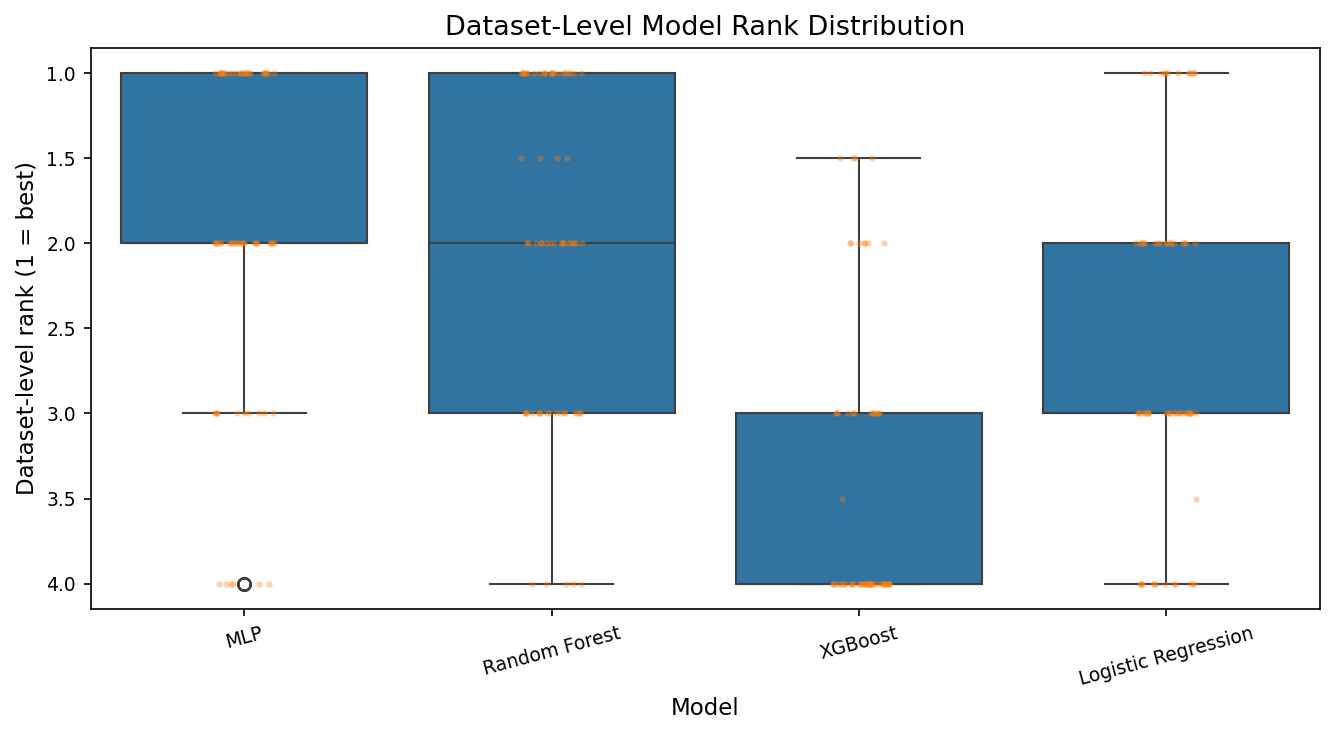

In [54]:
# Figure 4.6 — Formal average-rank distribution
rank_plot = rank_df_full.rename(columns=MODEL_LABELS)

# Count exact displayed ranks where possible; ties may create fractional ranks
rank_long = rank_plot.melt(var_name="Model", value_name="Rank")

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=rank_long, x="Model", y="Rank", ax=ax)
sns.stripplot(data=rank_long, x="Model", y="Rank", ax=ax, alpha=0.35, size=3)
ax.invert_yaxis()
ax.set_xlabel("Model")
ax.set_ylabel("Dataset-level rank (1 = best)")
ax.set_title("Dataset-Level Model Rank Distribution")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("figures/Fig4_6_Rank_Distribution.png")
plt.show()

Table 4.3 — Joint Ranking Frequencies
|                     |   Joint 1st |   2nd |   Other ranks |
|---------------------|-------------|-------|---------------|
| MLP                 |          28 |    25 |            16 |
| Random Forest       |          29 |    18 |            22 |
| XGBoost             |           5 |     7 |            57 |
| Logistic Regression |          13 |    17 |            39 |

Note: joint first-place counts are not mutually exclusive and may sum to more than the number of datasets.


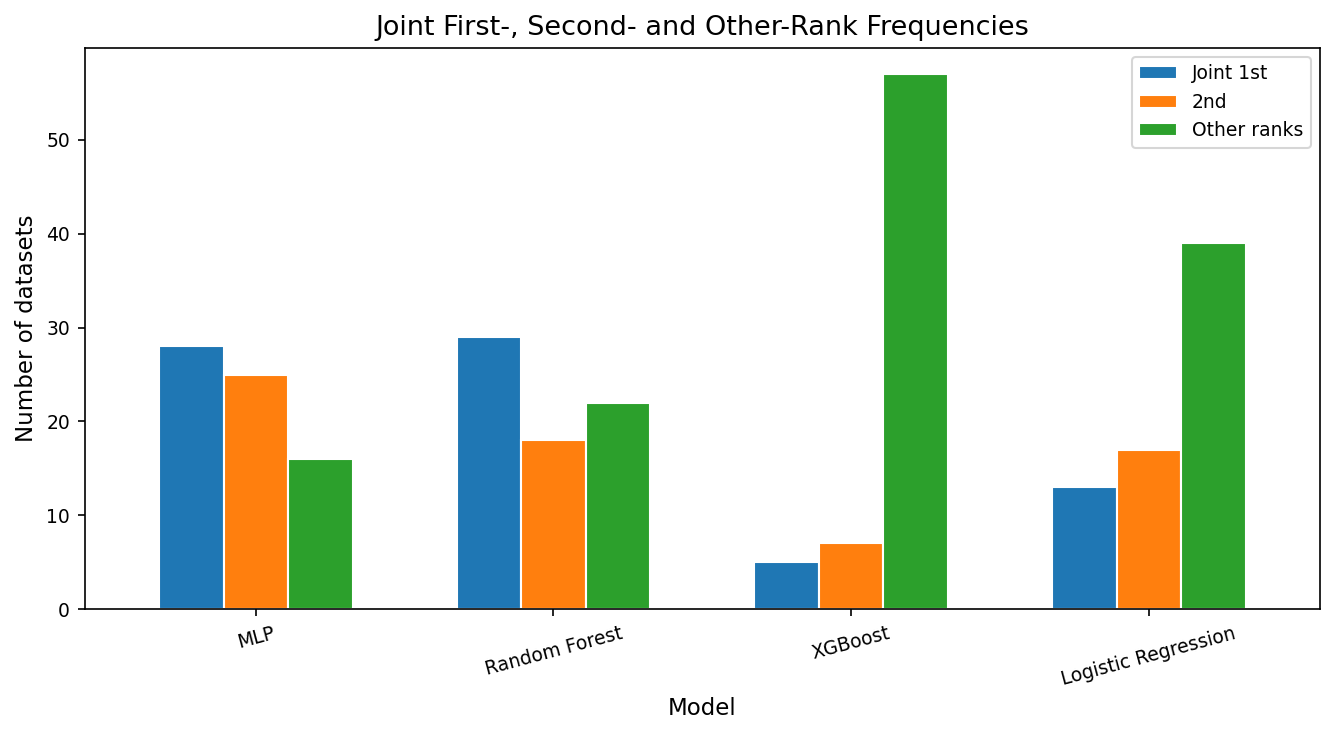

In [55]:
# Table 4.3 / Figure 4.7 — joint first-place, second-place and lower-rank frequencies
win_data = {}
for m in MODELS:
    label = MODEL_LABELS[m]
    joint_first = np.isclose(df[m], df[MODELS].max(axis=1)).sum()
    second = np.isclose(rank_df_full[m], 2.0).sum()
    lower = len(df) - joint_first - second
    win_data[label] = {
        "Joint 1st": int(joint_first),
        "2nd": int(second),
        "Other ranks": int(lower),
    }

win_df = pd.DataFrame(win_data).T
win_df.to_csv("tables/Table_4_3_Joint_Rank_Counts.csv")

print("Table 4.3 — Joint Ranking Frequencies")
print(tabulate(win_df, headers="keys", tablefmt="github"))
print("\nNote: joint first-place counts are not mutually exclusive and may sum to more than the number of datasets.")

fig, ax = plt.subplots(figsize=(9, 5))
win_df.plot(kind="bar", ax=ax, edgecolor="white", width=0.65)
ax.set_xlabel("Model")
ax.set_ylabel("Number of datasets")
ax.set_title("Joint First-, Second- and Other-Rank Frequencies")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("figures/Fig4_7_Win_Counts.png")
plt.show()

---
# Part 2 — Model Performance Comparison & Statistical Significance Testing
## Section 4.3: Comparative Model Performance

In [56]:
# Table 4.4 — Overall model performance summary with correct average ranks
summary_rows = []

for col, label in MODEL_LABELS.items():
    vals = df[col]
    joint_wins = np.isclose(df[col], df[MODELS].max(axis=1)).sum()
    summary_rows.append({
        "Model": label,
        "Mean BA": vals.mean(),
        "Std Dev": vals.std(ddof=1),
        "Median BA": vals.median(),
        "Joint first-place count": int(joint_wins),
        "Joint first-place rate (%)": 100 * joint_wins / len(df),
        "Average Rank": rank_df_full[col].mean(),
    })

table_44 = pd.DataFrame(summary_rows).sort_values("Average Rank")
table_44.to_csv("tables/Table_4_4_Model_Summary.csv", index=False)

print("Overall Model Performance Summary")
print(tabulate(table_44.round(4), headers="keys", tablefmt="github", showindex=False))

Overall Model Performance Summary
| Model               |   Mean BA |   Std Dev |   Median BA |   Joint first-place count |   Joint first-place rate (%) |   Average Rank |
|---------------------|-----------|-----------|-------------|---------------------------|------------------------------|----------------|
| MLP                 |    0.799  |    0.1894 |      0.868  |                        28 |                      40.5797 |         1.913  |
| Random Forest       |    0.7986 |    0.2002 |      0.8973 |                        29 |                      42.029  |         2.029  |
| Logistic Regression |    0.7543 |    0.1814 |      0.7814 |                        13 |                      18.8406 |         2.6014 |
| XGBoost             |    0.6611 |    0.17   |      0.5759 |                         5 |                       7.2464 |         3.4565 |


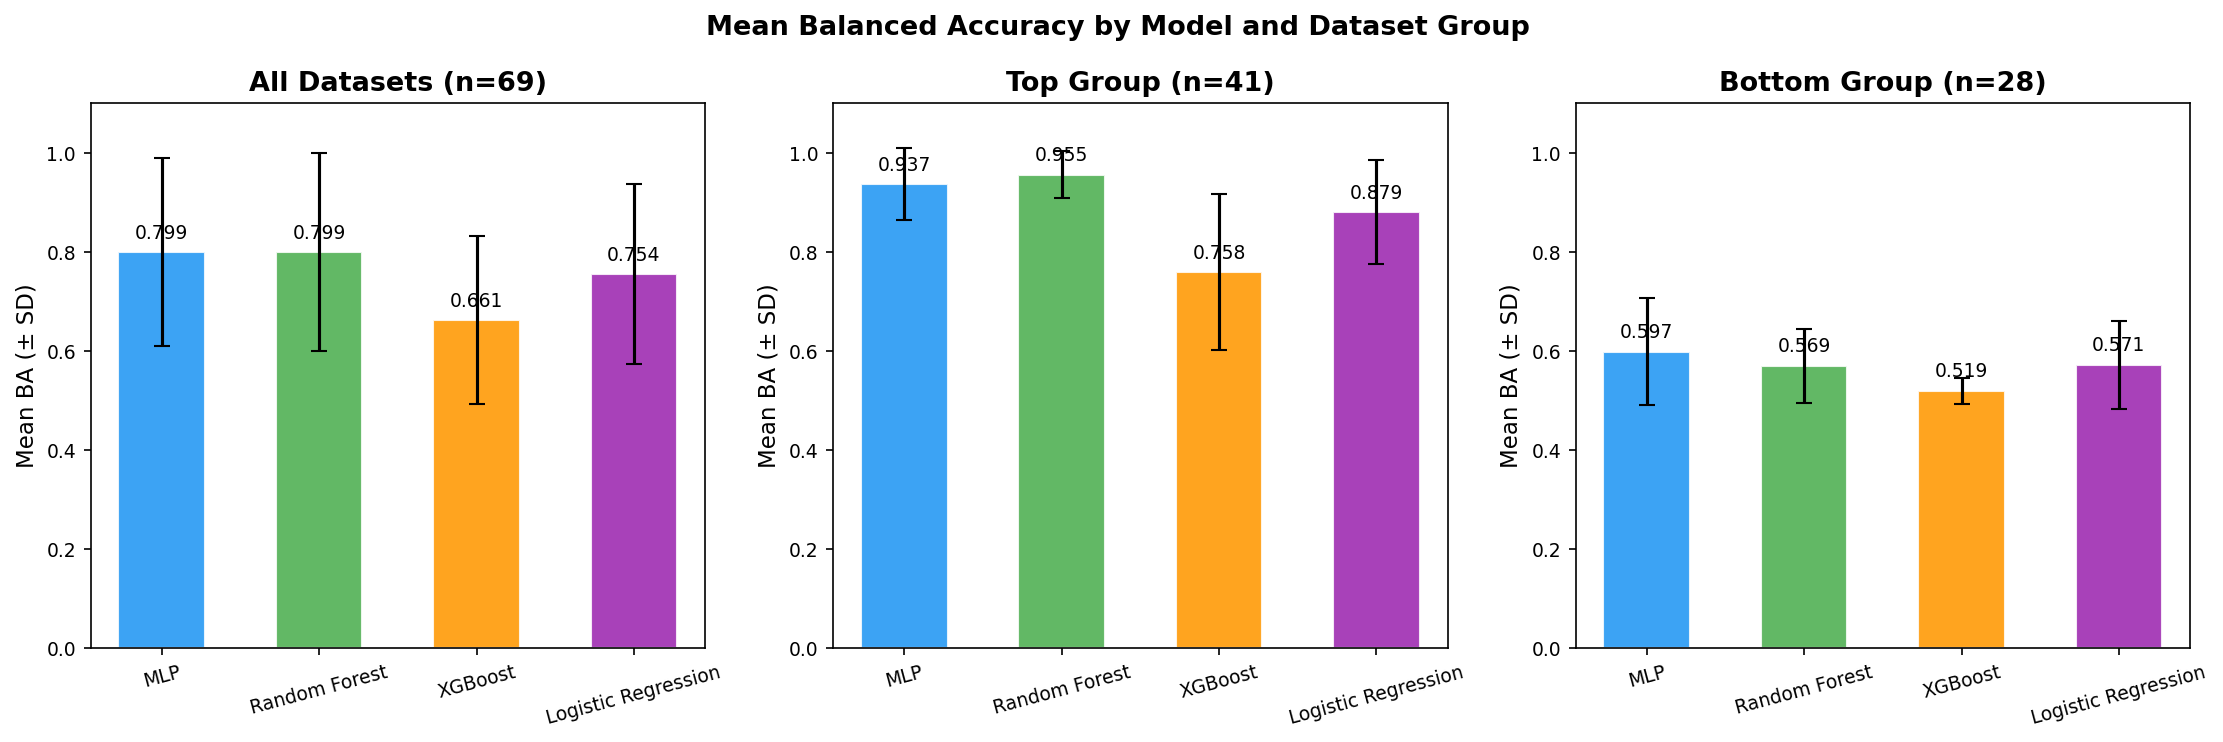

In [57]:
# ── Figure 4.8 — Mean BA grouped bar chart ───────────────────────────────────
def mean_ba_bar(ax, subset, title):
    labels_b = [MODEL_LABELS[m] for m in MODELS]
    means_b  = [subset[m].mean() for m in MODELS]
    sds_b    = [subset[m].std()  for m in MODELS]
    colors_b = [MODEL_COLORS["MLP"], MODEL_COLORS["RF"],
                MODEL_COLORS["XGB"], MODEL_COLORS["LR"]]
    bars = ax.bar(labels_b, means_b, yerr=sds_b, capsize=4,
                  color=colors_b, edgecolor="white", width=0.55, alpha=0.88)
    ax.set_ylim(0, 1.1); ax.set_ylabel("Mean BA (± SD)"); ax.set_title(title, fontweight="bold")
    for bar, v in zip(bars, means_b):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
mean_ba_bar(axes[0], df,           "All Datasets (n=69)")
mean_ba_bar(axes[1], df_top_group, "Top Group (n=41)")
mean_ba_bar(axes[2], df_bot_group, "Bottom Group (n=28)")
plt.suptitle("Mean Balanced Accuracy by Model and Dataset Group",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_8_MeanBA_Grouped.png"); plt.show()

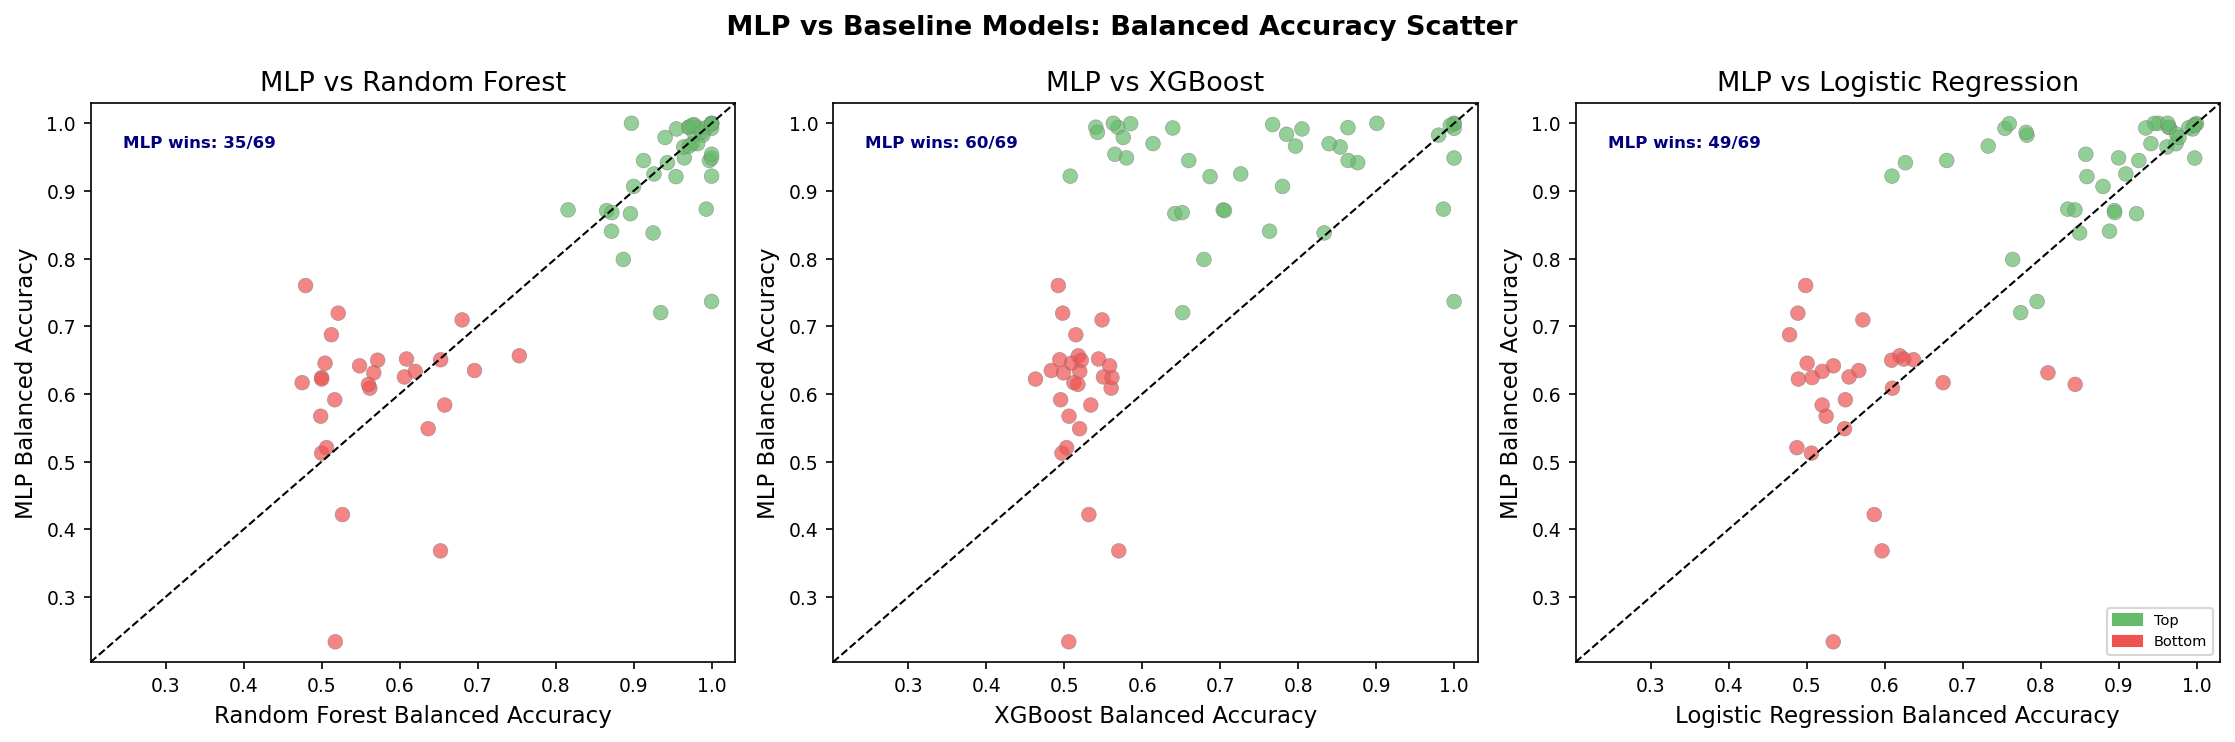

In [58]:
# ── Figure 4.9 — MLP vs each baseline scatter ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, b, bl in zip(axes,
                     ["RF_BA","XGB_BA","LR_BA"],
                     ["Random Forest","XGBoost","Logistic Regression"]):
    colors_pt = df["Dataset_Type"].map({"top":"#66BB6A","bottom":"#EF5350"})
    ax.scatter(df[b], df["MLP_BA"], c=colors_pt, alpha=0.7, s=50,
               edgecolors="grey", lw=0.3)
    lims = [min(df[b].min(), df["MLP_BA"].min())-0.03,
            max(df[b].max(), df["MLP_BA"].max())+0.03]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{bl} Balanced Accuracy")
    ax.set_ylabel("MLP Balanced Accuracy")
    ax.set_title(f"MLP vs {bl}")
    wins = (df["MLP_BA"] > df[b]).sum()
    ax.annotate(f"MLP wins: {wins}/{len(df)}",
                xy=(0.05, 0.92), xycoords="axes fraction",
                fontsize=8, color="navy", fontweight="bold")

top_p    = mpatches.Patch(color="#66BB6A", label="Top")
bottom_p = mpatches.Patch(color="#EF5350", label="Bottom")
axes[2].legend(handles=[top_p, bottom_p], fontsize=7, loc="lower right")
plt.suptitle(" MLP vs Baseline Models: Balanced Accuracy Scatter",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_9_MLP_vs_Baselines_Scatter.png"); plt.show()

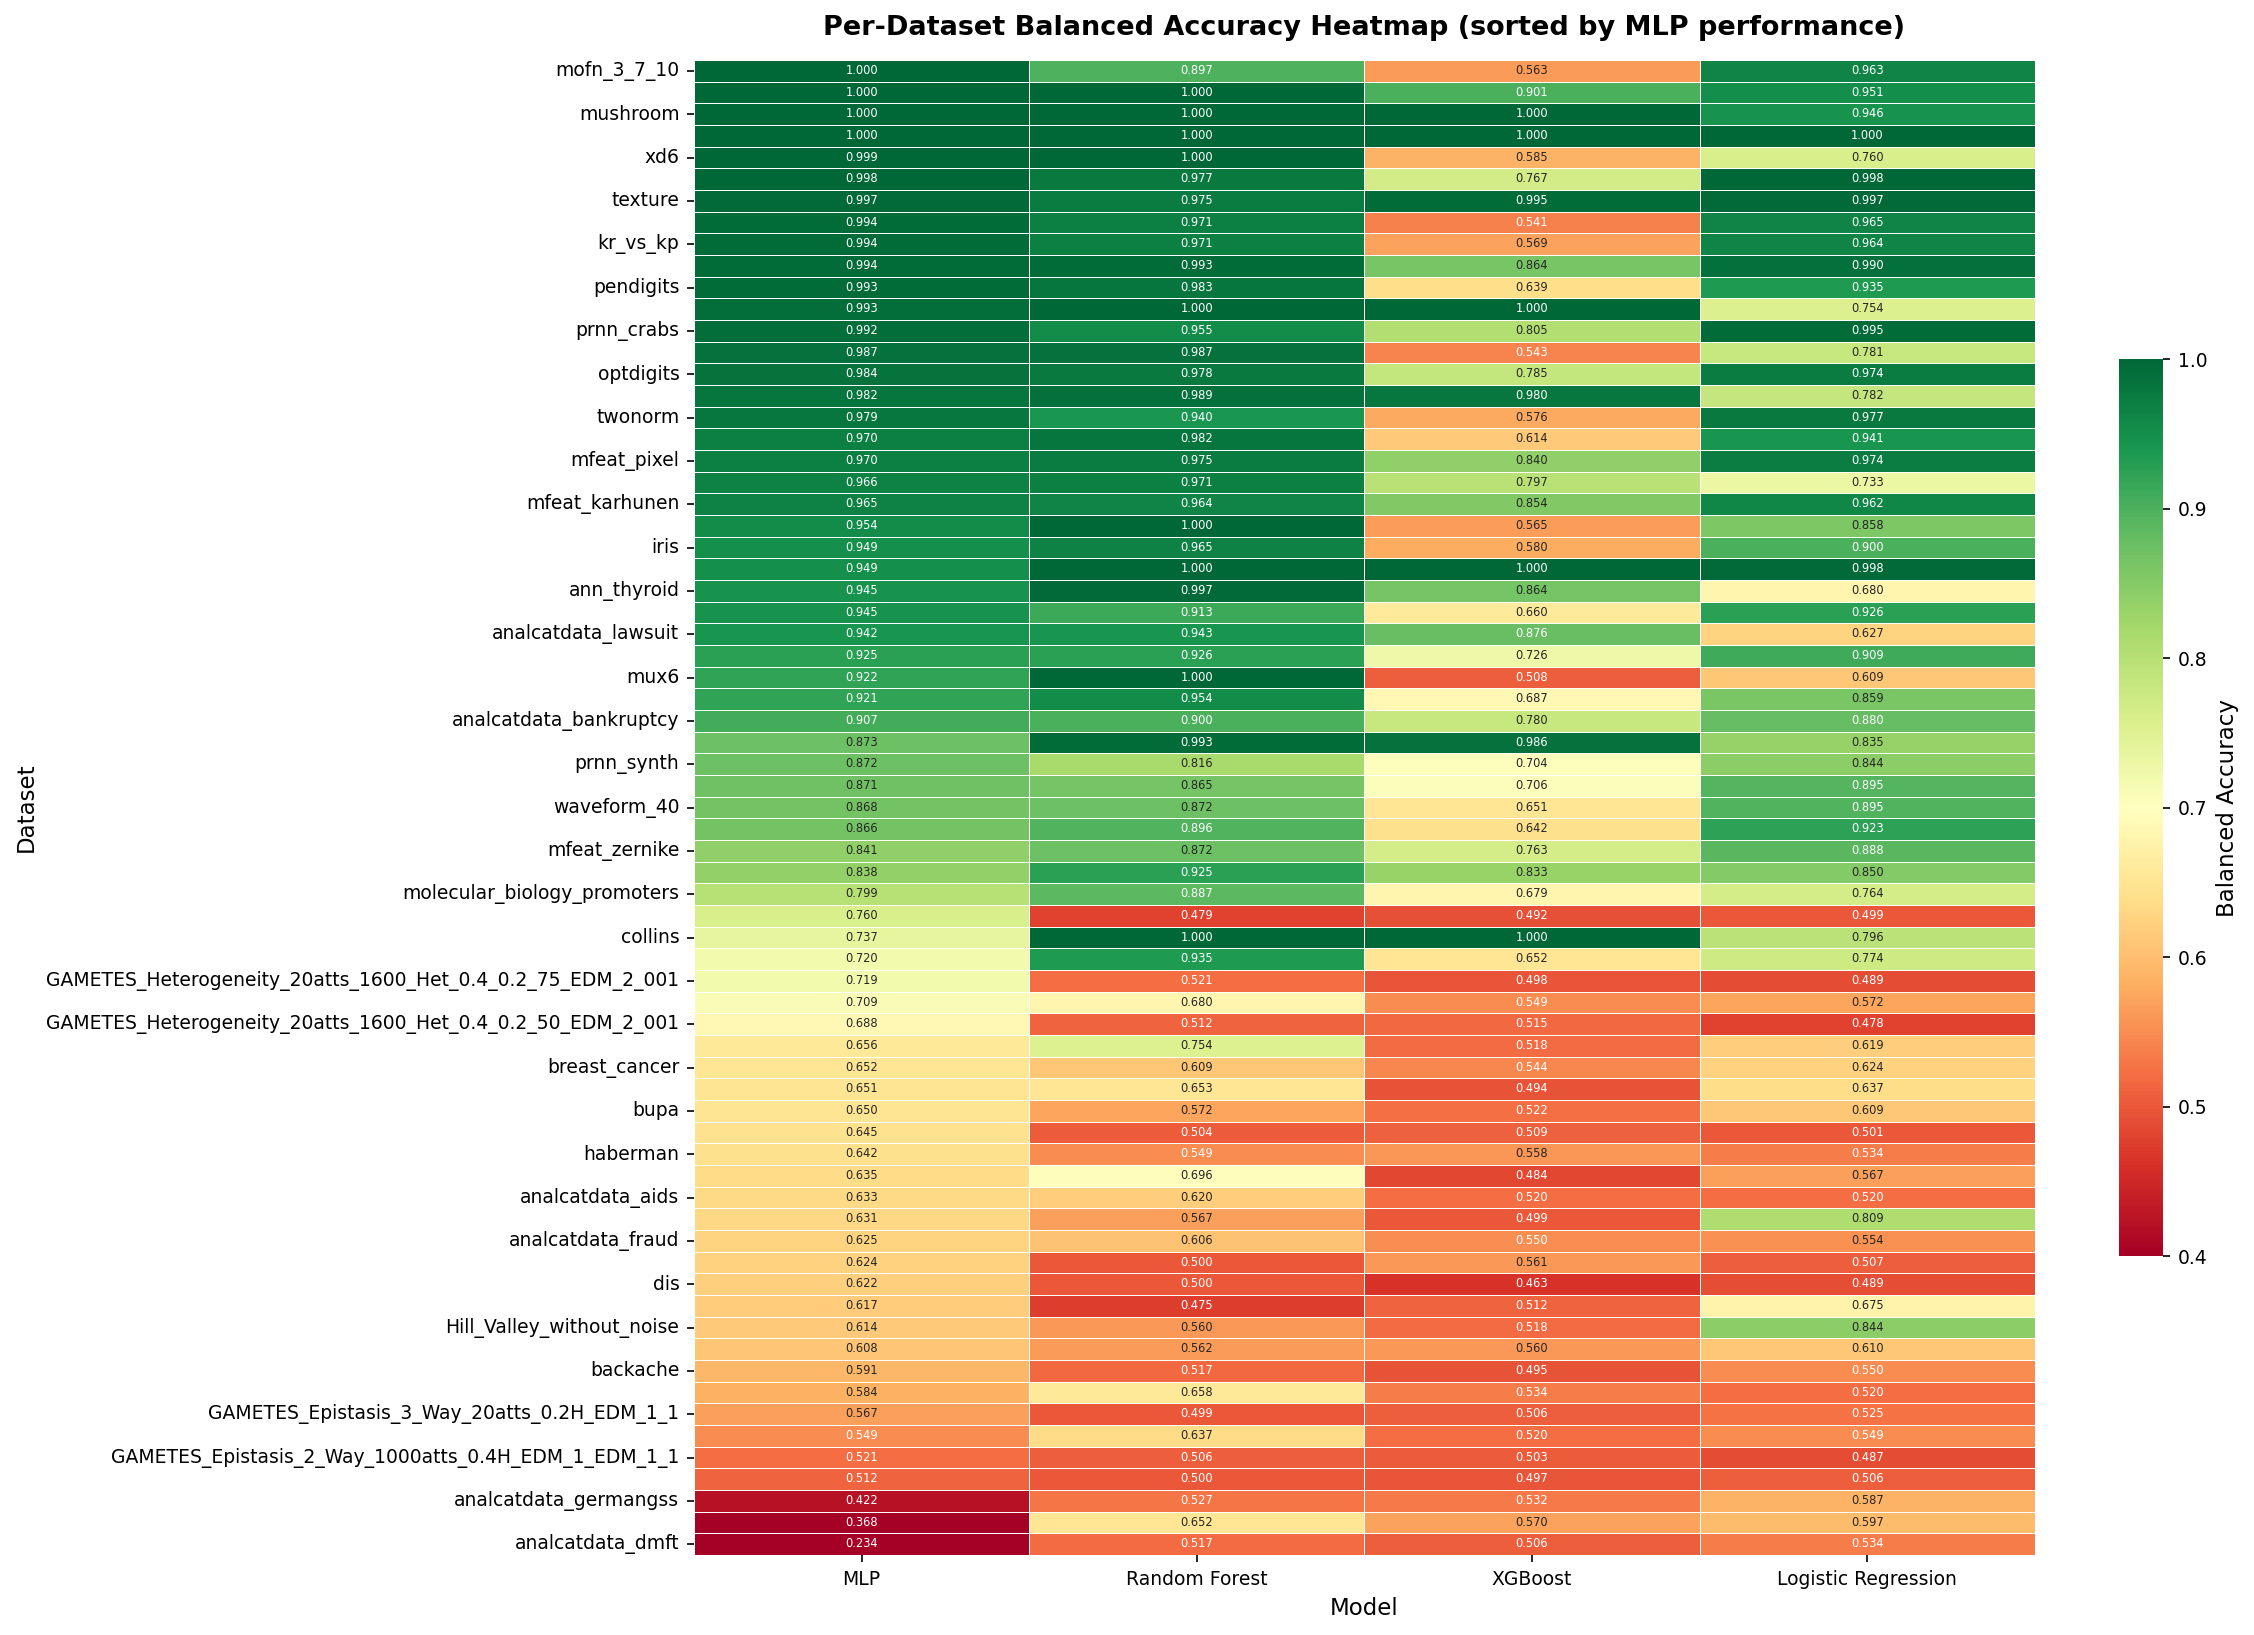

In [59]:
# ── Figure 4.10 — Per-dataset performance heatmap ────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11))
heat_df = df.set_index("Datasets")[MODELS].rename(columns=MODEL_LABELS)
heat_df = heat_df.sort_values("MLP", ascending=False)
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="RdYlGn",
            linewidths=0.3, ax=ax, vmin=0.4, vmax=1.0,
            cbar_kws={"shrink":0.6, "label":"Balanced Accuracy"},
            annot_kws={"size": 5.5})
ax.set_title("Per-Dataset Balanced Accuracy Heatmap (sorted by MLP performance)",
             fontweight="bold", pad=12)
ax.set_ylabel("Dataset"); ax.set_xlabel("Model")
plt.tight_layout()
plt.savefig("figures/Fig4_10_Performance_Heatmap.png"); plt.show()

## 4.4 Analysis of Difficult (Bottom) Datasets — RQ2

The **Bottom datasets are the primary operational representation of difficult datasets in this dissertation**. They were identified from comparatively poor performance by the conventional baseline models during the baseline stage of the experimental pipeline. The MLP outcome was not used to decide whether a dataset entered the Bottom group.

Accordingly, the Bottom-group analysis is the principal evidence used to address RQ2. A continuous baseline-difficulty measure is examined later only as a secondary robustness check.

In [60]:
# Table 4.5 — Bottom datasets and MLP margin over the strongest baseline
bot_detail = df_bot_group[
    ["Datasets", "MLP_BA", "RF_BA", "XGB_BA", "LR_BA",
     "Rows", "Features", "Classes", "Imbalance"]
].copy()

bot_detail["Best_Baseline"] = bot_detail[["RF_BA", "XGB_BA", "LR_BA"]].max(axis=1)
bot_detail["MLP_Margin"] = bot_detail["MLP_BA"] - bot_detail["Best_Baseline"]
bot_detail = bot_detail.sort_values("MLP_Margin", ascending=False).reset_index(drop=True)

bot_detail.to_csv("tables/Table_4_5_Bottom_Datasets.csv", index=False)

print("Bottom Datasets: MLP vs Strongest Conventional Baseline")
print(tabulate(
    bot_detail[["Datasets", "MLP_BA", "RF_BA", "XGB_BA", "LR_BA", "Best_Baseline", "MLP_Margin"]].round(4),
    headers="keys", tablefmt="github", showindex=False
))

print("\nBottom-group summary:")
print(f"Datasets: {len(bot_detail)}")
print(f"MLP > strongest baseline: {(bot_detail['MLP_Margin'] > 0).sum()}")
print(f"MLP = strongest baseline: {(bot_detail['MLP_Margin'] == 0).sum()}")
print(f"MLP < strongest baseline: {(bot_detail['MLP_Margin'] < 0).sum()}")
print(f"Mean MLP margin: {bot_detail['MLP_Margin'].mean():.4f}")
print(f"Median MLP margin: {bot_detail['MLP_Margin'].median():.4f}")

Bottom Datasets: MLP vs Strongest Conventional Baseline
| Datasets                                                   |   MLP_BA |   RF_BA |   XGB_BA |   LR_BA |   Best_Baseline |   MLP_Margin |
|------------------------------------------------------------|----------|---------|----------|---------|-----------------|--------------|
| GAMETES_Epistasis_2_Way_20atts_0.4H_EDM_1_1                |   0.7602 |  0.4794 |   0.4925 |  0.4988 |          0.4988 |       0.2615 |
| GAMETES_Heterogeneity_20atts_1600_Het_0.4_0.2_75_EDM_2_001 |   0.7194 |  0.5212 |   0.4981 |  0.4888 |          0.5212 |       0.1981 |
| GAMETES_Heterogeneity_20atts_1600_Het_0.4_0.2_50_EDM_2_001 |   0.6875 |  0.5125 |   0.515  |  0.4781 |          0.515  |       0.1725 |
| GAMETES_Epistasis_2_Way_20atts_0.1H_EDM_1_1                |   0.6454 |  0.5044 |   0.5094 |  0.5006 |          0.5094 |       0.136  |
| dis                                                        |   0.622  |  0.5    |   0.4633 |  0.4894 |          0.

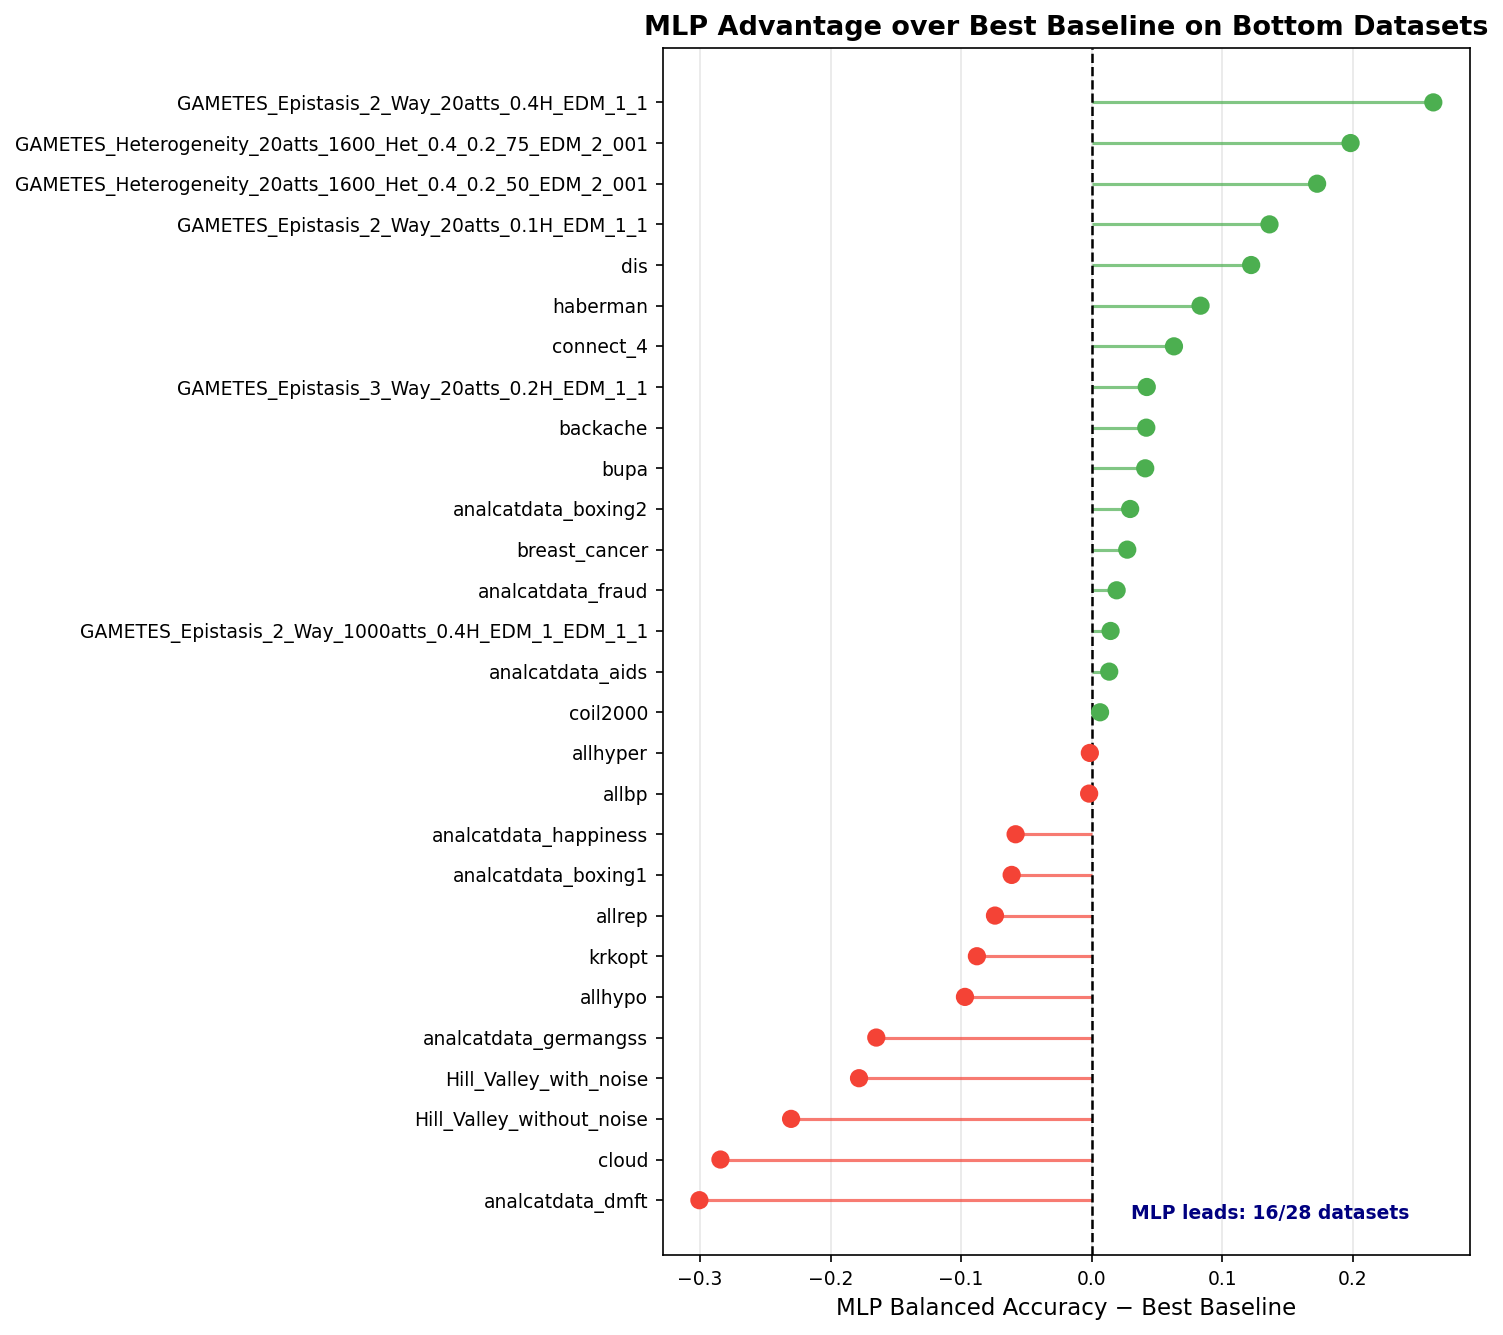

In [61]:
# ── Figure 4.11 — Lollipop: MLP margin on bottom datasets ────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
bot_s = bot_detail.sort_values("MLP_Margin")
colors_l = ["#4CAF50" if v >= 0 else "#F44336" for v in bot_s["MLP_Margin"]]
ax.hlines(y=bot_s["Datasets"], xmin=0, xmax=bot_s["MLP_Margin"],
          color=colors_l, linewidth=1.5, alpha=0.7)
ax.scatter(bot_s["MLP_Margin"], bot_s["Datasets"], color=colors_l, s=60, zorder=5)
ax.axvline(0, color="black", lw=1.2, ls="--")
ax.set_xlabel("MLP Balanced Accuracy − Best Baseline")
ax.set_title("MLP Advantage over Best Baseline on Bottom Datasets",
             fontweight="bold")
ax.grid(axis="x", alpha=0.3)
pos_wins = (bot_s["MLP_Margin"] >= 0).sum()
ax.annotate(f"MLP leads: {pos_wins}/{len(bot_s)} datasets",
            xy=(0.58, 0.03), xycoords="axes fraction",
            fontsize=9, color="navy", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_11_MLP_Margin_Bottom.png"); plt.show()

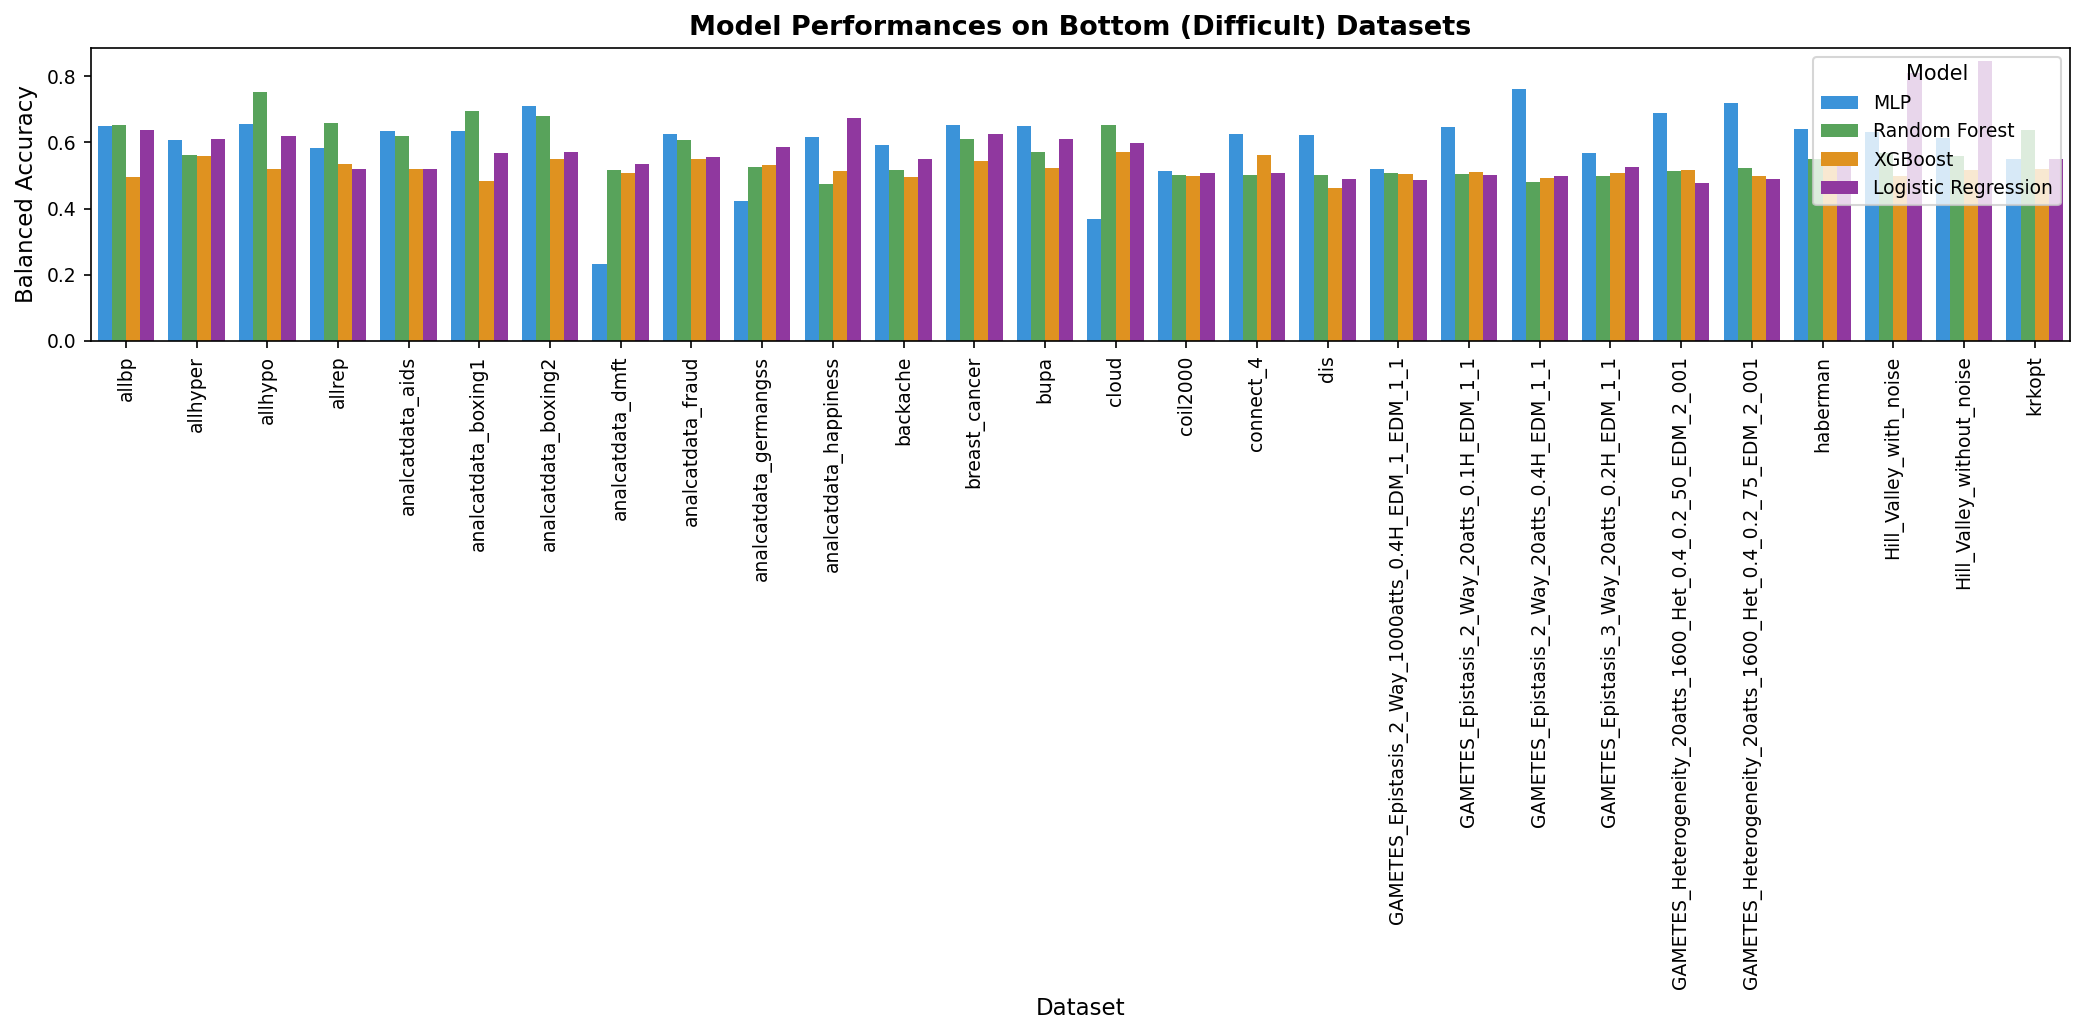

In [62]:
# ── Figure 4.12 — Grouped bar: all models on bottom datasets ─────────────────
bot_melt = df_bot_group.melt(id_vars="Datasets", value_vars=MODELS,
                              var_name="Model", value_name="BA")
bot_melt["Model"] = bot_melt["Model"].map(MODEL_LABELS)
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=bot_melt, x="Datasets", y="BA", hue="Model",
            palette=[MODEL_COLORS["MLP"], MODEL_COLORS["RF"],
                     MODEL_COLORS["XGB"], MODEL_COLORS["LR"]],
            ax=ax, errorbar=None)
ax.set_xlabel("Dataset"); ax.set_ylabel("Balanced Accuracy")
ax.set_title("Model Performances on Bottom (Difficult) Datasets",
             fontweight="bold")
ax.tick_params(axis="x", rotation=90)
ax.legend(title="Model", loc="upper right")
plt.tight_layout()
plt.savefig("figures/Fig4_12_Bottom_Datasets_Bar.png"); plt.show()

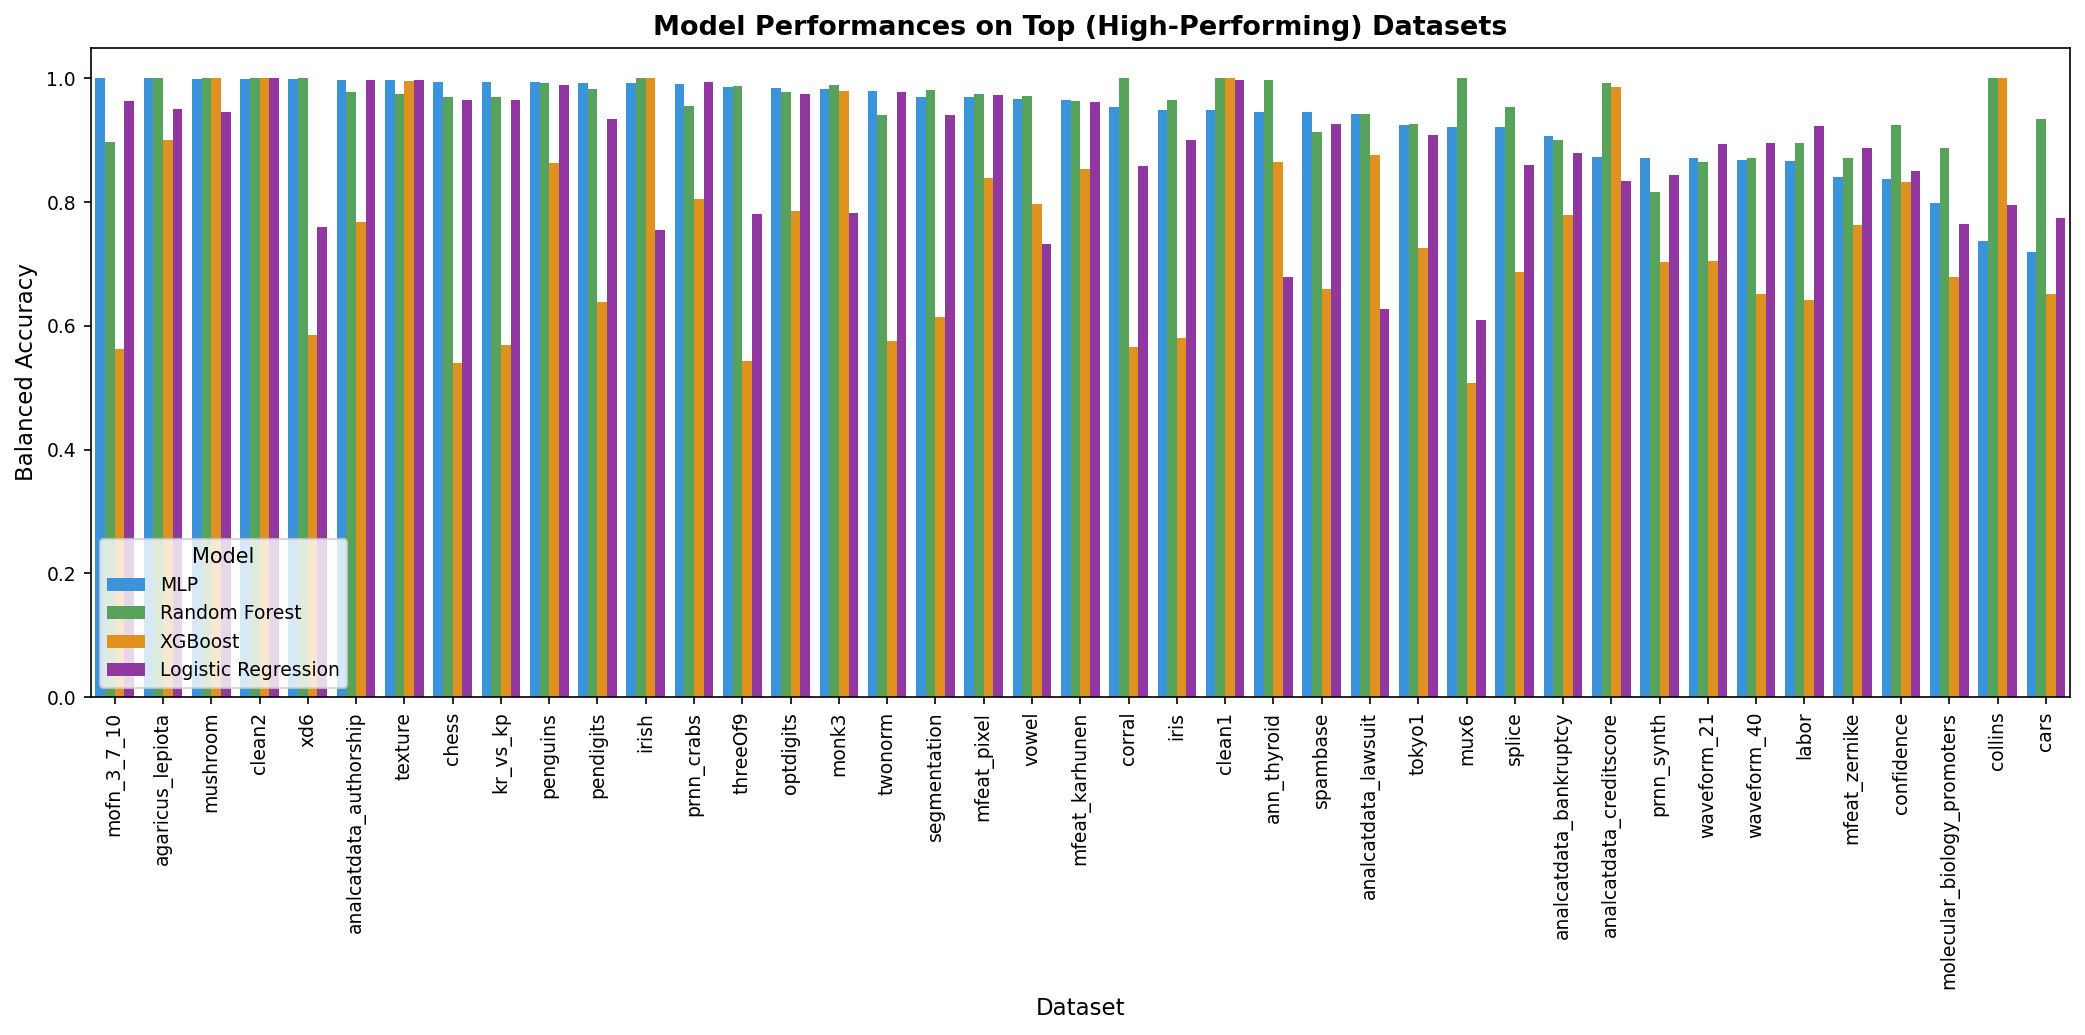

In [63]:
# ── Figure 4.13 — Grouped bar: all models on top datasets ────────────────────
top_melt  = df_top_group.melt(id_vars="Datasets", value_vars=MODELS,
                               var_name="Model", value_name="BA")
top_melt["Model"] = top_melt["Model"].map(MODEL_LABELS)
top_order = df_top_group.sort_values("MLP_BA", ascending=False)["Datasets"].tolist()
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=top_melt, x="Datasets", y="BA", hue="Model", order=top_order,
            palette=[MODEL_COLORS["MLP"], MODEL_COLORS["RF"],
                     MODEL_COLORS["XGB"], MODEL_COLORS["LR"]],
            ax=ax, errorbar=None)
ax.set_xlabel("Dataset"); ax.set_ylabel("Balanced Accuracy")
ax.set_title("Model Performances on Top (High-Performing) Datasets",
             fontweight="bold")
ax.tick_params(axis="x", rotation=90)
ax.legend(title="Model", loc="lower left")
plt.tight_layout()
plt.savefig("figures/Fig4_13_Top_Datasets_Bar.png"); plt.show()

## 4.5 Statistical Analysis — RQ1 and Supporting RQ2 Inference

The dataset is the unit of statistical comparison. Four-model omnibus tests use complete cases only. Planned MLP-versus-baseline Wilcoxon comparisons use Holm adjustment across the three related hypotheses.

A non-significant p-value is interpreted as **no statistically significant difference detected**, not as formal equivalence.

In [64]:
# Table 4.6 — Shapiro-Wilk diagnostic normality tests
norm_rows = []

for col, label in MODEL_LABELS.items():
    vals = df[col].dropna()
    stat, p = shapiro(vals)
    norm_rows.append({
        "Model": label,
        "W-statistic": stat,
        "p-value": p,
        "Interpretation": "Departure from normality detected" if p < 0.05 else "No significant departure detected",
    })

norm_df = pd.DataFrame(norm_rows)
norm_df.to_csv("tables/Table_4_6_Shapiro_Wilk.csv", index=False)

display_norm = norm_df.copy()
display_norm["W-statistic"] = display_norm["W-statistic"].map(lambda x: f"{x:.4f}")
display_norm["p-value"] = display_norm["p-value"].map(lambda x: "<0.001" if x < 0.001 else f"{x:.4f}")

print("Shapiro–Wilk Diagnostic Tests")
print(tabulate(display_norm, headers="keys", tablefmt="github", showindex=False))
print("\nThese tests are diagnostic; non-parametric methods are retained because of the paired, heterogeneous dataset-level benchmark structure.")

Shapiro–Wilk Diagnostic Tests
| Model               |   W-statistic | p-value   | Interpretation                    |
|---------------------|---------------|-----------|-----------------------------------|
| MLP                 |        0.8789 | <0.001    | Departure from normality detected |
| Random Forest       |        0.8086 | <0.001    | Departure from normality detected |
| XGBoost             |        0.8508 | <0.001    | Departure from normality detected |
| Logistic Regression |        0.8931 | <0.001    | Departure from normality detected |

These tests are diagnostic; non-parametric methods are retained because of the paired, heterogeneous dataset-level benchmark structure.


### 4.5.2 Friedman Omnibus Test (Table 4.X)

In [65]:
# Table 4.7 — Friedman omnibus test on complete-case datasets
friedman_stat, friedman_p = friedmanchisquare(
    df_complete["MLP_BA"].values,
    df_complete["RF_BA"].values,
    df_complete["XGB_BA"].values,
    df_complete["LR_BA"].values,
)

n_complete = len(df_complete)
k_models = len(MODELS)
kendalls_w = friedman_stat / (n_complete * (k_models - 1))

fried_df = pd.DataFrame([{
    "Complete datasets": n_complete,
    "Friedman chi-square": friedman_stat,
    "df": k_models - 1,
    "p-value": friedman_p,
    "Kendall's W": kendalls_w,
    "Decision at alpha=.05": "Reject H0" if friedman_p < 0.05 else "Fail to reject H0",
}])

fried_df.to_csv("tables/Table_4_7_Friedman_Omnibus_Test.csv", index=False)

display_fried = fried_df.copy()
display_fried["Friedman chi-square"] = display_fried["Friedman chi-square"].map(lambda x: f"{x:.4f}")
display_fried["p-value"] = display_fried["p-value"].map(lambda x: "<0.001" if x < 0.001 else f"{x:.6f}")
display_fried["Kendall's W"] = display_fried["Kendall's W"].map(lambda x: f"{x:.4f}")

print("Friedman Omnibus Test")
print(tabulate(display_fried, headers="keys", tablefmt="github", showindex=False))

Friedman Omnibus Test
|   Complete datasets |   Friedman chi-square |   df | p-value   |   Kendall's W | Decision at alpha=.05   |
|---------------------|-----------------------|------|-----------|---------------|-------------------------|
|                  69 |               62.5683 |    3 | <0.001    |        0.3023 | Reject H0               |


### 4.5.3 Post-hoc Nemenyi Test (Table 4.8 / Figure 4.14)

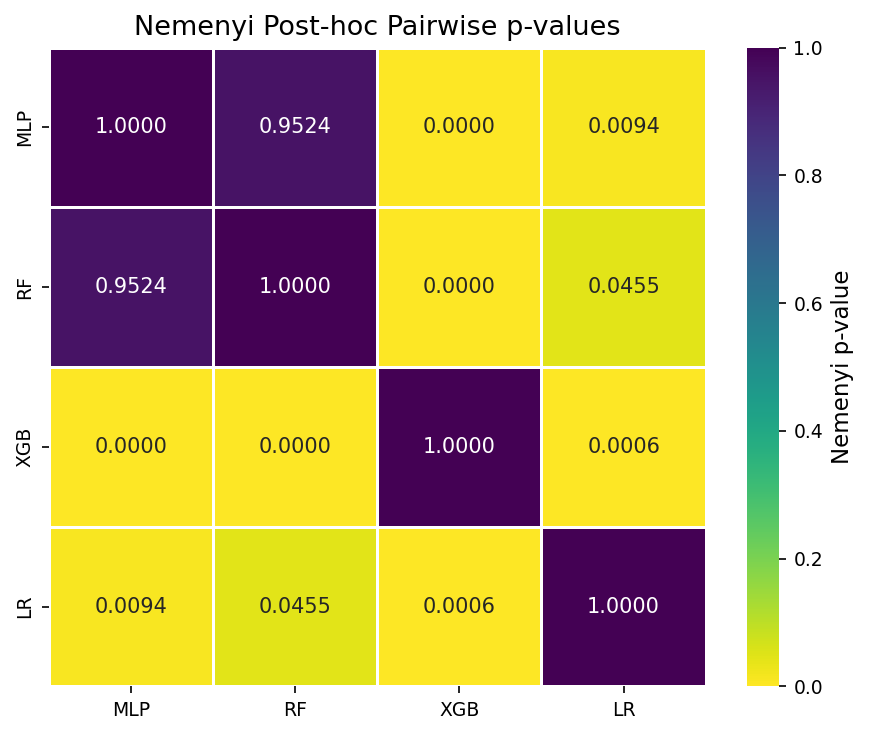

Nemenyi p-values
|     |      MLP |       RF |     XGB |       LR |
|-----|----------|----------|---------|----------|
| MLP | 1        | 0.952447 | 0       | 0.009404 |
| RF  | 0.952447 | 1        | 0       | 0.045468 |
| XGB | 0        | 0        | 1       | 0.00058  |
| LR  | 0.009404 | 0.045468 | 0.00058 | 1        |

Interpretation rule: p < .05 indicates a statistically significant rank difference.


In [67]:
# Table 4.8 / Figure 4.14 — Nemenyi post-hoc analysis, conditional on valid significant Friedman result
if np.isfinite(friedman_stat) and np.isfinite(friedman_p) and friedman_p < 0.05:
    perf_matrix = df_complete[MODELS].values
    nemenyi = sp.posthoc_nemenyi_friedman(perf_matrix)
    nemenyi.index = MODEL_SHORT
    nemenyi.columns = MODEL_SHORT
    nemenyi.to_csv("tables/Table_4_8_Nemenyi_Test.csv")

    pvals = nemenyi.values.astype(float)
    sig_mask = pvals < 0.05

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        nemenyi,
        cmap="viridis_r",
        annot=True,
        fmt=".4f",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Nemenyi p-value"},
    )
    ax.set_title("Nemenyi Post-hoc Pairwise p-values")
    plt.tight_layout()
    plt.savefig("figures/Fig4_14_Nemenyi_Heatmap.png")
    plt.show()

    print("Nemenyi p-values")
    print(tabulate(nemenyi.round(6), headers="keys", tablefmt="github"))
    print("\nInterpretation rule: p < .05 indicates a statistically significant rank difference.")
else:
    nemenyi = None
    print("Nemenyi post-hoc analysis not interpreted because the Friedman prerequisite was not satisfied.")

### 4.5.4 Pairwise MLP-Baseline Comparisons (Table 4.3)

In [68]:
# Table 4.9 — Planned pairwise MLP-baseline Wilcoxon comparisons with Holm adjustment

def matched_rank_biserial(x, y):
    d = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    if len(d) == 0:
        return np.nan
    ranks = stats.rankdata(np.abs(d))
    w_pos = ranks[d > 0].sum()
    w_neg = ranks[d < 0].sum()
    return (w_pos - w_neg) / (w_pos + w_neg)

pairwise_rows = []

for baseline_col in ["RF_BA", "XGB_BA", "LR_BA"]:
    sub = df_complete[["MLP_BA", baseline_col]].dropna()
    diff = sub["MLP_BA"] - sub[baseline_col]

    if np.allclose(diff, 0):
        W, p = np.nan, 1.0
    else:
        W, p = wilcoxon(
            sub["MLP_BA"],
            sub[baseline_col],
            zero_method="wilcox",
            alternative="two-sided",
        )

    pairwise_rows.append({
        "Comparison": f"MLP vs {MODEL_LABELS[baseline_col]}",
        "N": len(sub),
        "MLP wins": int((diff > 0).sum()),
        "MLP losses": int((diff < 0).sum()),
        "Ties": int((diff == 0).sum()),
        "Wilcoxon W": W,
        "Raw p-value": p,
        "Median BA difference": diff.median(),
        "Q1 difference": diff.quantile(0.25),
        "Q3 difference": diff.quantile(0.75),
        "Rank-biserial effect": matched_rank_biserial(sub["MLP_BA"], sub[baseline_col]),
    })

pairwise_df = pd.DataFrame(pairwise_rows)
reject, p_adj, _, _ = multipletests(pairwise_df["Raw p-value"], alpha=0.05, method="holm")
pairwise_df["Holm-adjusted p-value"] = p_adj
pairwise_df["Significant after Holm"] = reject
pairwise_df["Interpretation"] = np.where(
    reject,
    "Statistically significant paired difference detected",
    "No statistically significant paired difference detected"
)

pairwise_df.to_csv("tables/Table_4_9_Pairwise_MLP_Baseline_Comparisons.csv", index=False)

display_pairwise = pairwise_df.copy()
for c in ["Raw p-value", "Holm-adjusted p-value"]:
    display_pairwise[c] = display_pairwise[c].map(lambda x: "<0.001" if x < 0.001 else f"{x:.6f}")
for c in ["Median BA difference", "Q1 difference", "Q3 difference", "Rank-biserial effect"]:
    display_pairwise[c] = display_pairwise[c].map(lambda x: f"{x:.4f}")

print("Planned Pairwise MLP-Baseline Comparisons")
print(tabulate(display_pairwise, headers="keys", tablefmt="github", showindex=False))

Planned Pairwise MLP-Baseline Comparisons
| Comparison                 |   N |   MLP wins |   MLP losses |   Ties |   Wilcoxon W | Raw p-value   |   Median BA difference |   Q1 difference |   Q3 difference |   Rank-biserial effect | Holm-adjusted p-value   | Significant after Holm   | Interpretation                                          |
|----------------------------|-----|------------|--------------|--------|--------------|---------------|------------------------|-----------------|-----------------|------------------------|-------------------------|--------------------------|---------------------------------------------------------|
| MLP vs Random Forest       |  69 |         35 |           34 |      0 |         1111 | 0.563961      |                 0.0003 |         -0.0312 |          0.0386 |                 0.0799 | 0.563961                | False                    | No statistically significant paired difference detected |
| MLP vs XGBoost             |  69 |         60 |   

In [69]:
# Table 4.10 — RQ2 paired comparisons within the Bottom (difficult) dataset group
bottom_rows = []

for baseline_col in ["RF_BA", "XGB_BA", "LR_BA"]:
    sub = df_bot_group[["MLP_BA", baseline_col]].dropna()
    diff = sub["MLP_BA"] - sub[baseline_col]

    if np.allclose(diff, 0):
        W, p = np.nan, 1.0
    else:
        W, p = wilcoxon(
            sub["MLP_BA"],
            sub[baseline_col],
            zero_method="wilcox",
            alternative="two-sided",
        )

    bottom_rows.append({
        "Comparison": f"MLP vs {MODEL_LABELS[baseline_col]}",
        "N": len(sub),
        "MLP wins": int((diff > 0).sum()),
        "MLP losses": int((diff < 0).sum()),
        "Ties": int((diff == 0).sum()),
        "W": W,
        "Raw p-value": p,
        "Median BA difference": diff.median(),
        "Rank-biserial effect": matched_rank_biserial(sub["MLP_BA"], sub[baseline_col]),
    })

bottom_pairwise = pd.DataFrame(bottom_rows)
reject_b, p_adj_b, _, _ = multipletests(bottom_pairwise["Raw p-value"], alpha=0.05, method="holm")
bottom_pairwise["Holm-adjusted p-value"] = p_adj_b
bottom_pairwise["Significant after Holm"] = reject_b
bottom_pairwise["Interpretation"] = np.where(
    reject_b,
    "Statistically significant paired difference detected",
    "No statistically significant paired difference detected"
)

bottom_pairwise.to_csv("tables/Table_4_10_RQ2_Bottom_Wilcoxon_Holm.csv", index=False)

print("RQ2 Bottom-Group Planned Pairwise Comparisons")
print(tabulate(bottom_pairwise.round(6), headers="keys", tablefmt="github", showindex=False))

# Optional supplementary omnibus Bottom-group comparison
bottom_complete = df_bot_group.dropna(subset=MODELS)
if len(bottom_complete) >= 2:
    bottom_fried = friedmanchisquare(
        bottom_complete["MLP_BA"],
        bottom_complete["RF_BA"],
        bottom_complete["XGB_BA"],
        bottom_complete["LR_BA"],
    )
    print(f"\nSupplementary Bottom-group Friedman: chi2={bottom_fried.statistic:.4f}, "
          f"p={'<0.001' if bottom_fried.pvalue < 0.001 else f'{bottom_fried.pvalue:.6f}'}")

RQ2 Bottom-Group Planned Pairwise Comparisons
| Comparison                 |   N |   MLP wins |   MLP losses |   Ties |   W |   Raw p-value |   Median BA difference |   Rank-biserial effect |   Holm-adjusted p-value | Significant after Holm   | Interpretation                                          |
|----------------------------|-----|------------|--------------|--------|-----|---------------|------------------------|------------------------|-------------------------|--------------------------|---------------------------------------------------------|
| MLP vs Random Forest       |  28 |         20 |            8 |      0 | 132 |      0.109252 |               0.044749 |               0.349754 |                0.218503 | False                    | No statistically significant paired difference detected |
| MLP vs XGBoost             |  28 |         25 |            3 |      0 |  67 |      0.001289 |               0.100313 |               0.669951 |                0.003868 | True       

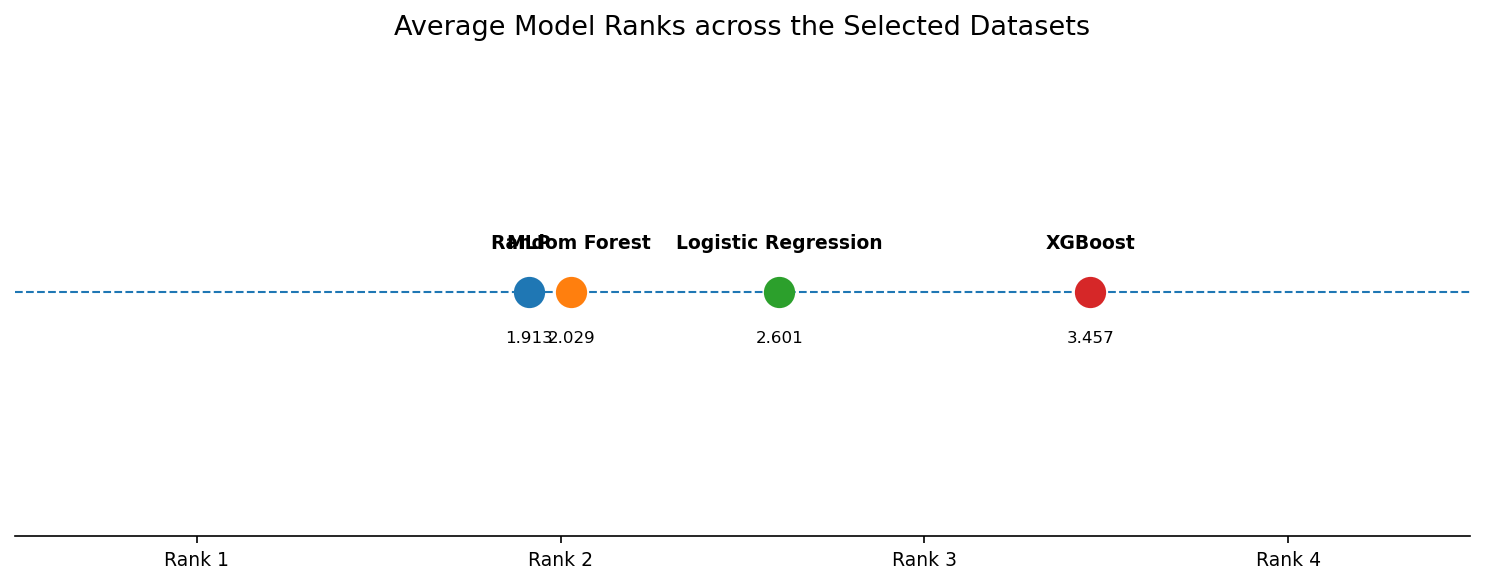

Average ranks:
MLP                    1.9130
Random Forest          2.0290
Logistic Regression    2.6014
XGBoost                3.4565


In [70]:
# Figure 4.15 — Average rank diagram across the common analytical sample
avg_ranks = rank_df_full.mean().sort_values()
avg_ranks.index = [MODEL_LABELS[c] for c in avg_ranks.index]

fig, ax = plt.subplots(figsize=(10, 4))
for label, rank in avg_ranks.items():
    ax.plot([rank], [0.5], "o", ms=14, zorder=5)
    ax.text(rank, 0.58, label, ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(rank, 0.42, f"{rank:.3f}", ha="center", va="top", fontsize=8)

ax.axhline(0.5, linewidth=1, linestyle="--")
ax.set_xlim(0.5, 4.5)
ax.set_ylim(0, 1)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Rank 1", "Rank 2", "Rank 3", "Rank 4"])
ax.set_yticks([])
ax.set_title("Average Model Ranks across the Selected Datasets")
ax.spines[["left", "right", "top"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/Fig4_15_Average_Rank_Diagram.png")
plt.show()

print("Average ranks:")
print(avg_ranks.round(4).to_string())

---
# Part 3 — Meta-Feature Analysis, PCA & Export Utilities
## Section 4.6: Dataset Characteristics and Meta-Feature Analysis

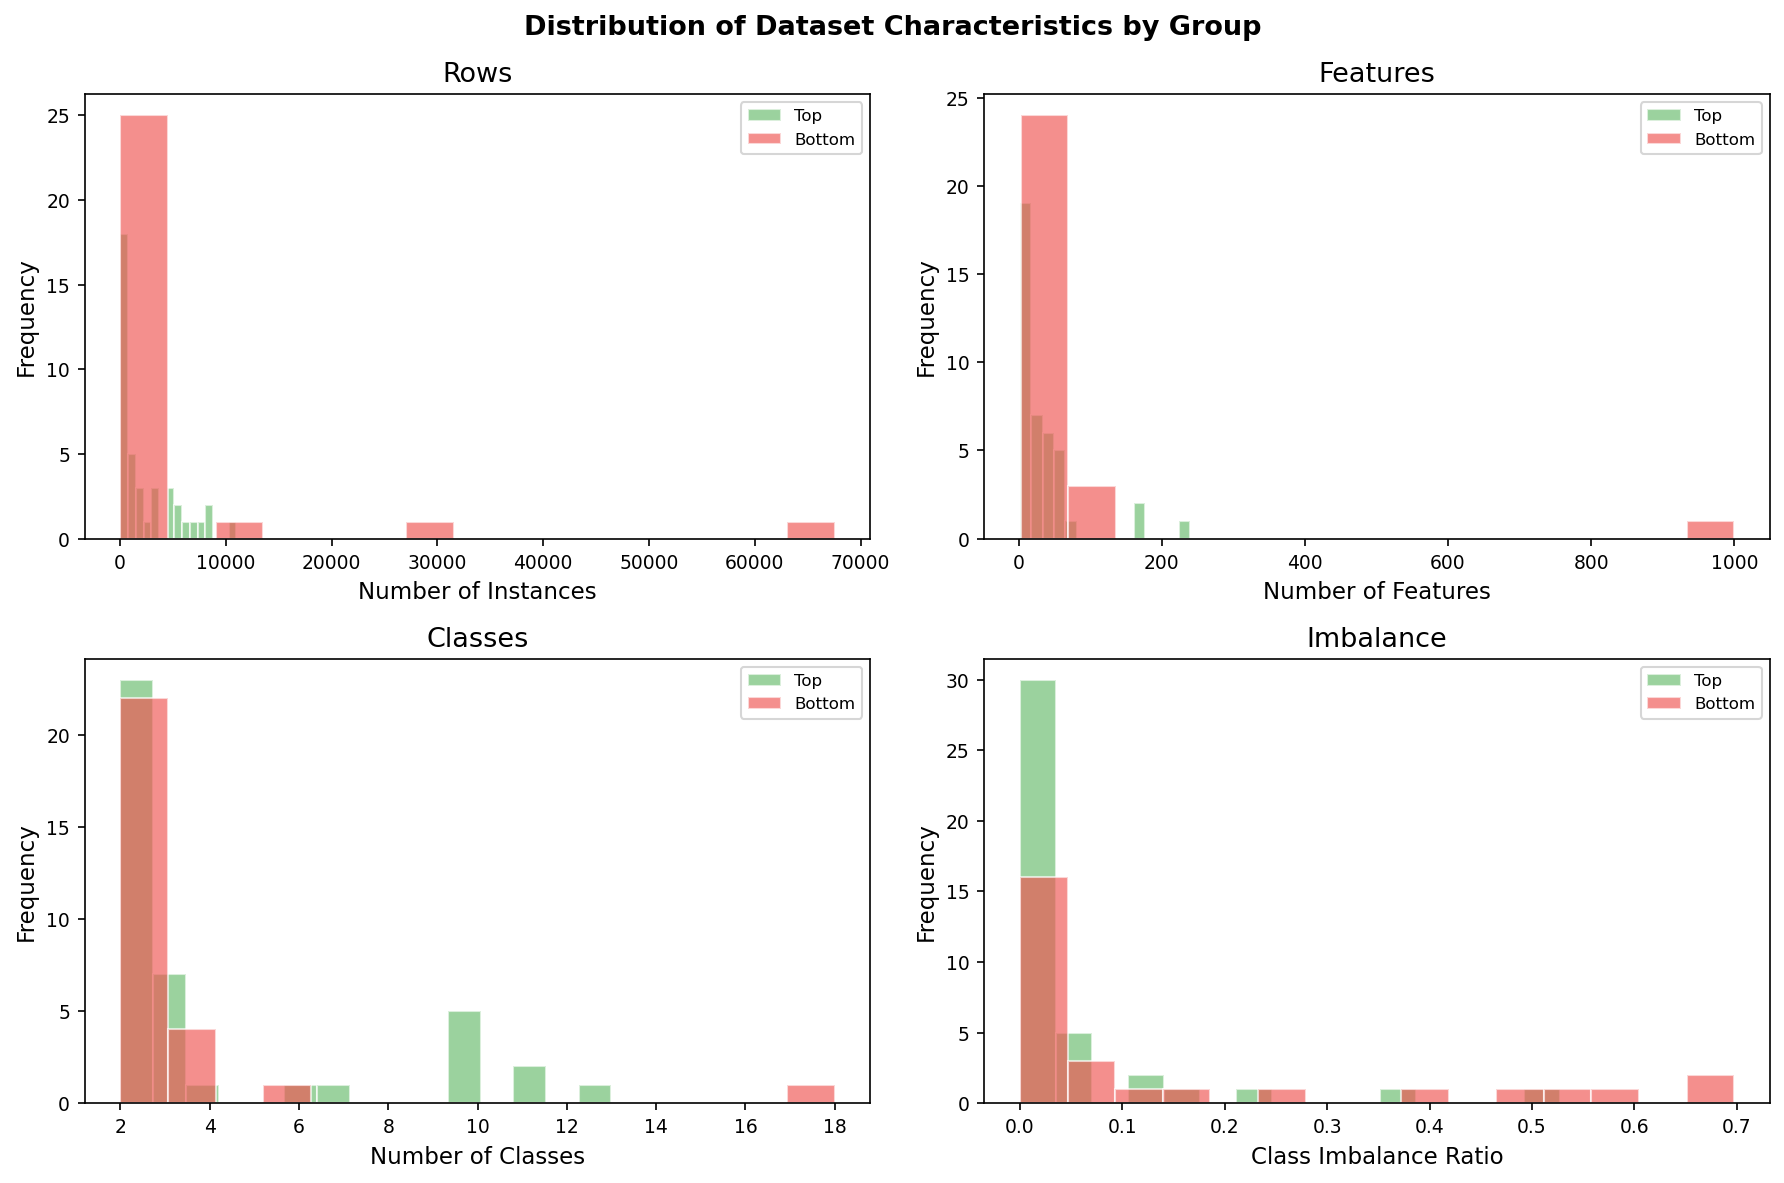

In [71]:
# ── Figure 4.16 — Dataset characteristic distributions ───────────────────────
char_plot = [("Rows","Number of Instances","#42A5F5"),
             ("Features","Number of Features","#66BB6A"),
             ("Classes","Number of Classes","#FFA726"),
             ("Imbalance","Class Imbalance Ratio","#AB47BC")]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, xlabel, _) in zip(axes.flatten(), char_plot):
    ax.hist(df_top_group[col].values, bins=15, alpha=0.65,
            color="#66BB6A", label="Top",    edgecolor="white")
    ax.hist(df_bot_group[col].values, bins=15, alpha=0.65,
            color="#EF5350", label="Bottom", edgecolor="white")
    ax.set_xlabel(xlabel); ax.set_ylabel("Frequency")
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle("Distribution of Dataset Characteristics by Group",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_16_Dataset_Characteristics.png"); plt.show()

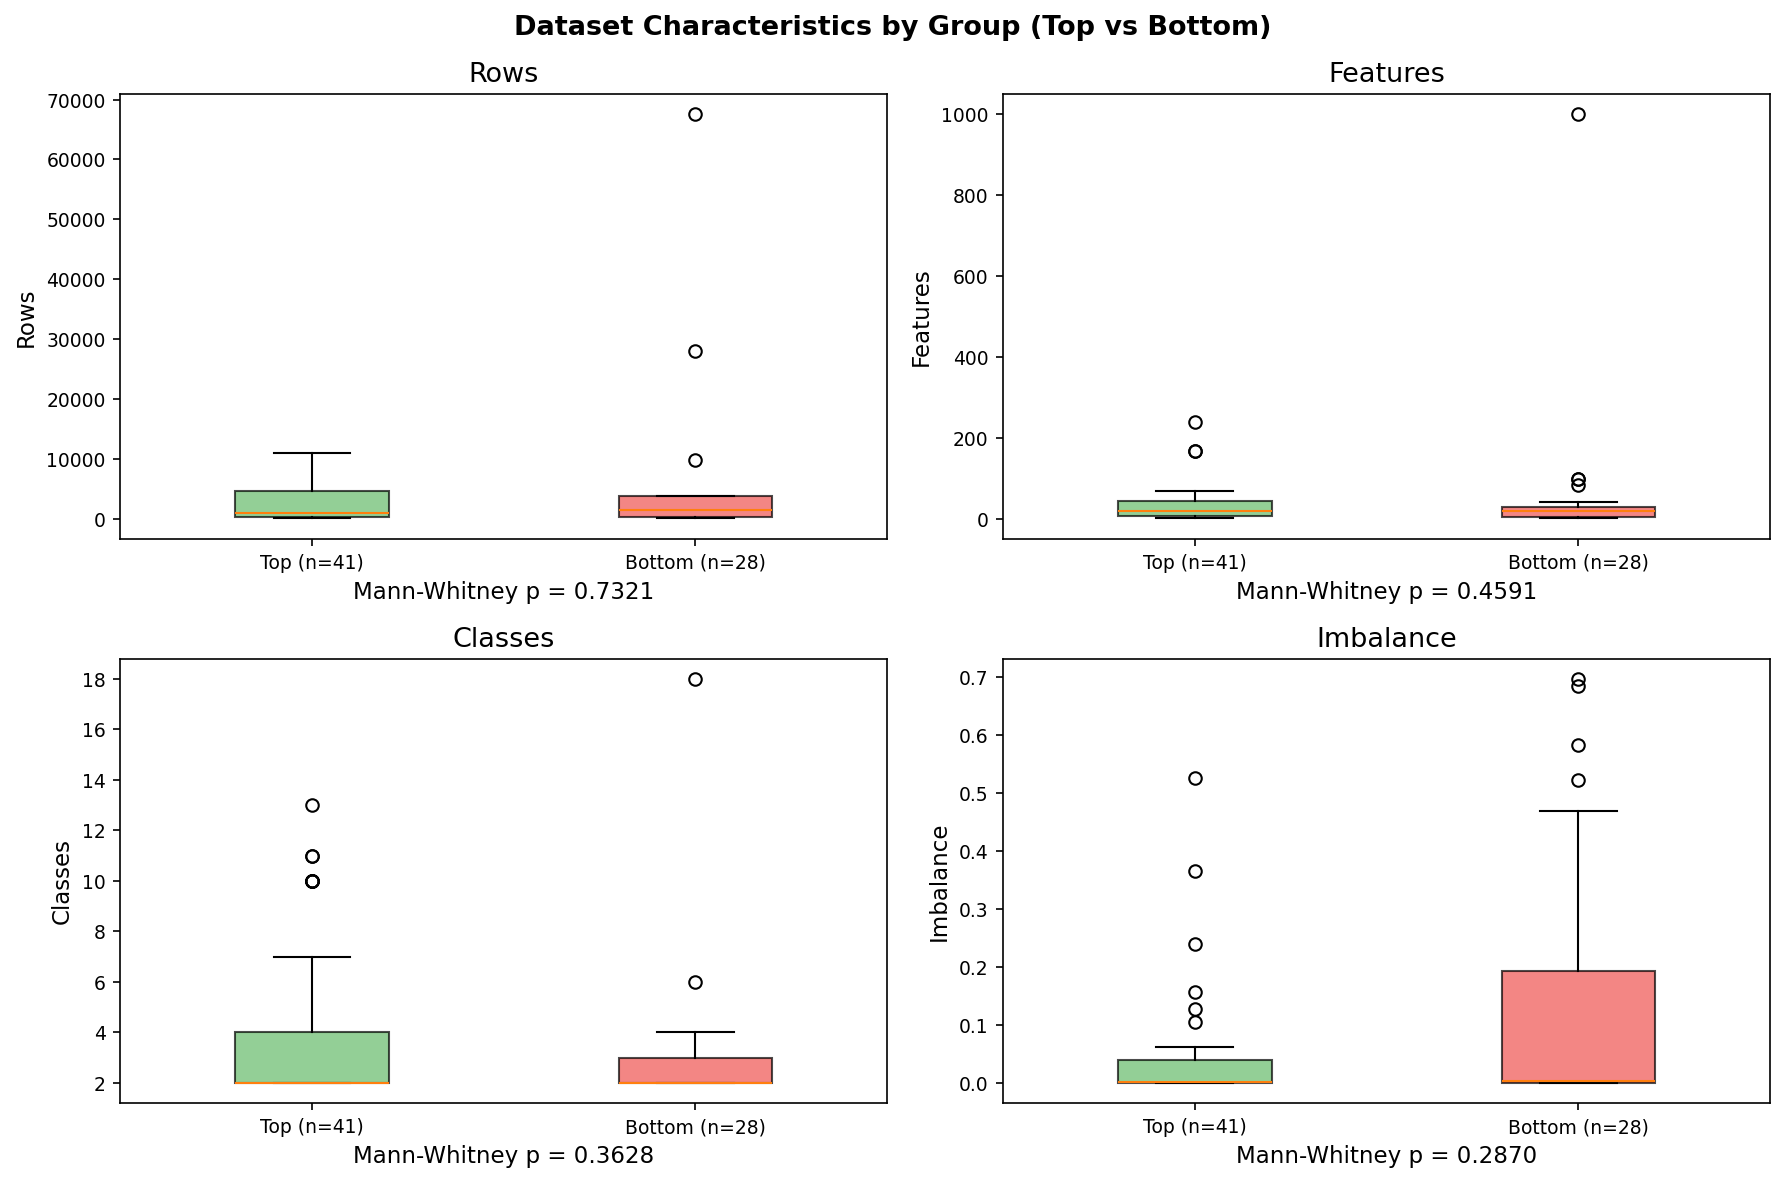

In [72]:
# ── Figure 4.17 — Characteristic boxplots: top vs bottom ─────────────────────
char_list = ["Rows","Features","Classes","Imbalance"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), char_list):
    bp = ax.boxplot([df_top_group[col].values, df_bot_group[col].values],
                    labels=["Top (n=41)","Bottom (n=28)"],
                    patch_artist=True, widths=0.4)
    bp["boxes"][0].set_facecolor("#66BB6A"); bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#EF5350"); bp["boxes"][1].set_alpha(0.7)
    stat, p = mannwhitneyu(df_top_group[col], df_bot_group[col], alternative="two-sided")
    ax.set_title(col); ax.set_ylabel(col)
    ax.set_xlabel(f"Mann-Whitney p = {p:.4f}" + (" *" if p < 0.05 else ""))
plt.suptitle("Dataset Characteristics by Group (Top vs Bottom)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_17_Characteristics_Boxplot.png"); plt.show()

## 4.6 Dataset Characteristics and MLP Competitiveness — RQ3

RQ3 concerns **relative MLP competitiveness**, not merely absolute MLP balanced accuracy. The response variable for the primary RQ3 analyses is therefore the MLP margin:

\[
\Delta_{MLP,i}=BA_{MLP,i}-\max(BA_{LR,i},BA_{RF,i},BA_{XGB,i})
\]

Constant meta-features are excluded because they contain no between-dataset information. Exact duplicate predictors are also removed from the multivariable meta-model to avoid redundant inputs.

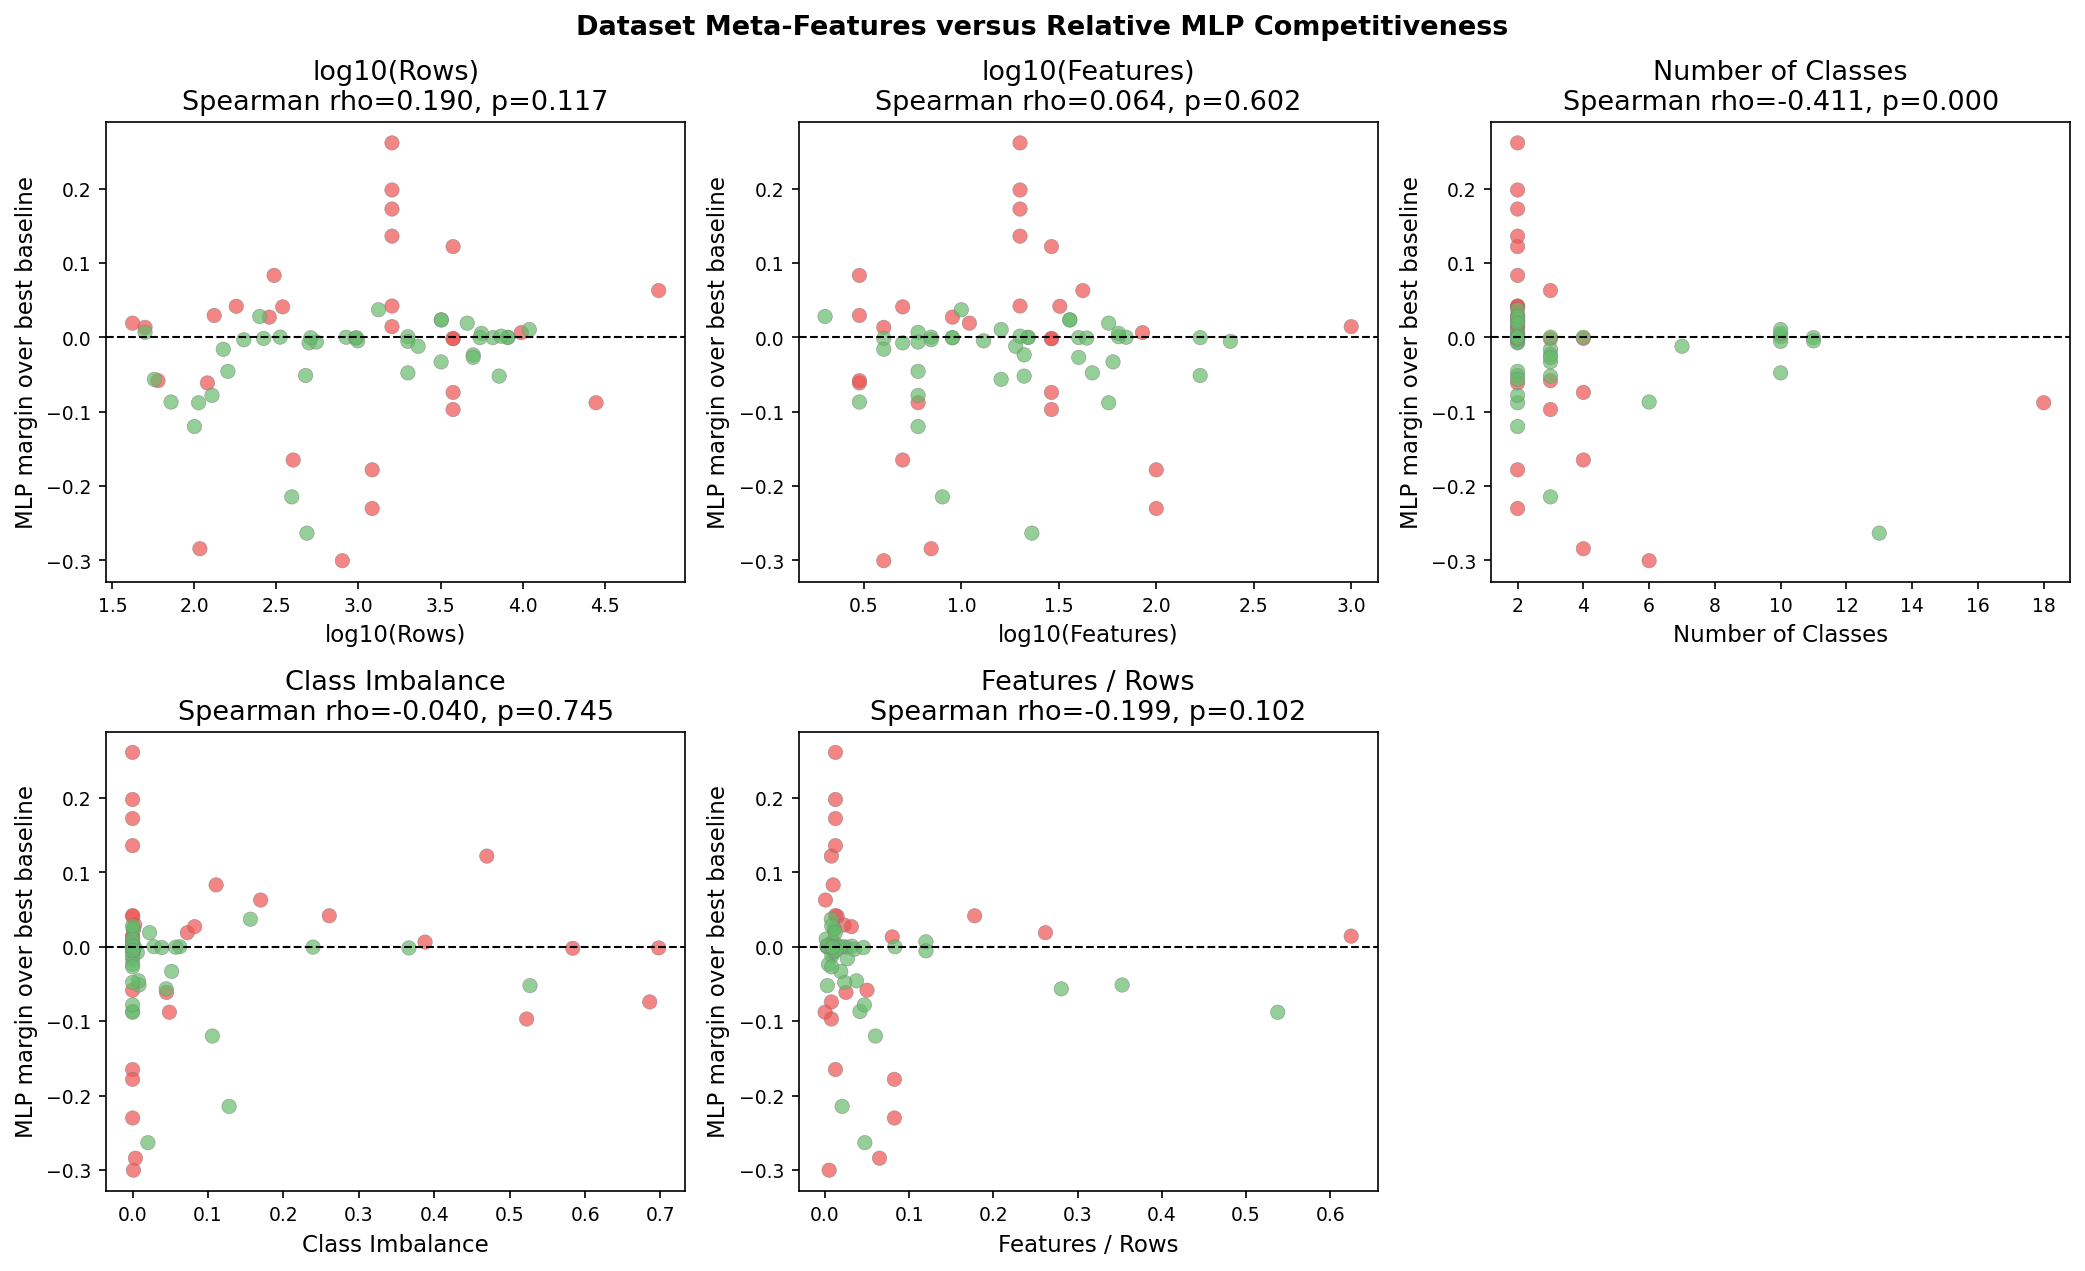

In [73]:
# Figure 4.18 — Dataset meta-features versus MLP performance margin
candidate_plot_features = [
    ("log_Rows", "log10(Rows)"),
    ("log_Features", "log10(Features)"),
    ("Classes", "Number of Classes"),
    ("Imbalance", "Class Imbalance"),
    ("Feat_Row_Ratio", "Features / Rows"),
]

available_plot_features = [
    (feat, label) for feat, label in candidate_plot_features
    if feat in df.columns and df[feat].dropna().nunique() > 1
]

nplots = len(available_plot_features)
ncols = 3
nrows = int(np.ceil(nplots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.3 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, (feat, label) in zip(axes, available_plot_features):
    valid = df[[feat, "MLP_vs_Best", "Dataset_Type"]].dropna()
    colors_pt = valid["Dataset_Type"].map({"top": "#66BB6A", "bottom": "#EF5350"})

    ax.scatter(
        valid[feat],
        valid["MLP_vs_Best"],
        c=colors_pt,
        alpha=0.7,
        s=48,
        edgecolors="grey",
        linewidths=0.3,
    )
    ax.axhline(0, color="black", linewidth=1, linestyle="--")

    rho, p = stats.spearmanr(valid[feat], valid["MLP_vs_Best"])
    ax.set_xlabel(label)
    ax.set_ylabel("MLP margin over best baseline")
    ax.set_title(f"{label}\nSpearman rho={rho:.3f}, p={p:.3f}")

for ax in axes[nplots:]:
    ax.set_visible(False)

plt.suptitle("Dataset Meta-Features versus Relative MLP Competitiveness",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_18_Features_vs_MLP_Margin.png")
plt.show()

In [74]:
# Table 4.11 — Pearson and Spearman correlations with MLP performance margin
candidate_features = [
    "Rows",
    "Features",
    "Classes",
    "Imbalance",
    "Numeric_Features",
    "Categorical_Features",
    "Missing_Values_Ratio",
    "Feat_Row_Ratio",
]

correlation_rows = []
excluded_features = []

for feat in candidate_features:
    if feat not in df.columns:
        continue

    valid = df[[feat, "MLP_vs_Best"]].replace([np.inf, -np.inf], np.nan).dropna()

    if valid[feat].nunique() <= 1:
        excluded_features.append((feat, "constant / no variation"))
        continue

    r, p_pearson = stats.pearsonr(valid[feat], valid["MLP_vs_Best"])
    rho, p_spearman = stats.spearmanr(valid[feat], valid["MLP_vs_Best"])

    correlation_rows.append({
        "Feature": feat,
        "N": len(valid),
        "Pearson r": r,
        "Pearson raw p": p_pearson,
        "Spearman rho": rho,
        "Spearman raw p": p_spearman,
    })

corr_tbl = pd.DataFrame(correlation_rows)

if len(corr_tbl):
    _, pearson_adj, _, _ = multipletests(corr_tbl["Pearson raw p"], alpha=0.05, method="holm")
    _, spearman_adj, _, _ = multipletests(corr_tbl["Spearman raw p"], alpha=0.05, method="holm")

    corr_tbl["Pearson Holm p"] = pearson_adj
    corr_tbl["Spearman Holm p"] = spearman_adj
    corr_tbl["Pearson significant"] = corr_tbl["Pearson Holm p"] < 0.05
    corr_tbl["Spearman significant"] = corr_tbl["Spearman Holm p"] < 0.05
    corr_tbl["Absolute Spearman rho"] = corr_tbl["Spearman rho"].abs()
    corr_tbl = corr_tbl.sort_values("Absolute Spearman rho", ascending=False)

corr_tbl.to_csv("tables/Table_4_11_RQ3_Feature_Correlations_MLP_Margin.csv", index=False)

print("Dataset Meta-Feature Associations with MLP Competitiveness")
print(tabulate(corr_tbl.round(6), headers="keys", tablefmt="github", showindex=False))

if excluded_features:
    print("\nExcluded from correlation analysis:")
    for feat, reason in excluded_features:
        print(f"  - {feat}: {reason}")

Dataset Meta-Feature Associations with MLP Competitiveness
| Feature          |   N |   Pearson r |   Pearson raw p |   Spearman rho |   Spearman raw p |   Pearson Holm p |   Spearman Holm p | Pearson significant   | Spearman significant   |   Absolute Spearman rho |
|------------------|-----|-------------|-----------------|----------------|------------------|------------------|-------------------|-----------------------|------------------------|-------------------------|
| Classes          |  69 |   -0.247342 |        0.040462 |      -0.410512 |         0.000459 |         0.242774 |          0.002756 | False                 | True                   |                0.410512 |
| Feat_Row_Ratio   |  69 |   -0.088237 |        0.470927 |      -0.198525 |         0.101993 |         1        |          0.509963 | False                 | False                  |                0.198525 |
| Rows             |  69 |    0.106401 |        0.384213 |       0.190345 |         0.117209 |         1 

### 4.6.3 Supplementary Top-versus-Bottom Meta-Feature Comparison

This supplementary analysis describes whether the preselected Top and Bottom groups differ in basic dataset characteristics. It does **not** replace the primary RQ3 correlation analysis against MLP competitiveness.

In [75]:
# Table 4.12 — Supplementary Top-versus-Bottom meta-feature comparisons
group_feature_rows = []

for feat in ["Rows", "Features", "Classes", "Imbalance", "Feat_Row_Ratio"]:
    if feat not in df.columns or df[feat].dropna().nunique() <= 1:
        continue

    top_vals = df_top_group[feat].dropna()
    bottom_vals = df_bot_group[feat].dropna()
    U, p = mannwhitneyu(top_vals, bottom_vals, alternative="two-sided")

    group_feature_rows.append({
        "Feature": feat,
        "Top median": top_vals.median(),
        "Bottom median": bottom_vals.median(),
        "Mann-Whitney U": U,
        "Raw p-value": p,
    })

group_feature_df = pd.DataFrame(group_feature_rows)

if len(group_feature_df):
    _, group_adj, _, _ = multipletests(group_feature_df["Raw p-value"], alpha=0.05, method="holm")
    group_feature_df["Holm-adjusted p-value"] = group_adj
    group_feature_df["Significant after Holm"] = group_feature_df["Holm-adjusted p-value"] < 0.05

group_feature_df.to_csv("tables/Table_4_12_Top_Bottom_MetaFeature_Comparisons.csv", index=False)
print("Supplementary Top-versus-Bottom Meta-Feature Comparison")
print(tabulate(group_feature_df.round(6), headers="keys", tablefmt="github", showindex=False))

Supplementary Top-versus-Bottom Meta-Feature Comparison
| Feature        |   Top median |   Bottom median |   Mann-Whitney U |   Raw p-value |   Holm-adjusted p-value | Significant after Holm   |
|----------------|--------------|-----------------|------------------|---------------|-------------------------|--------------------------|
| Rows           |   973        |     1406        |            602.5 |      0.73212  |                       1 | False                    |
| Features       |    20        |       20        |            635   |      0.45914  |                       1 | False                    |
| Classes        |     2        |        2        |            640.5 |      0.362821 |                       1 | False                    |
| Imbalance      |     0.000788 |        0.003321 |            488   |      0.287017 |                       1 | False                    |
| Feat_Row_Ratio |     0.017578 |        0.0125   |            585   |      0.897864 |                  

### 4.6.4 Exploratory Meta-Model and Validated Feature Importance

A Random Forest regressor is used only as an exploratory multivariable analysis of the MLP performance margin. Before interpreting feature importance, the model is evaluated using repeated cross-validation.

Features with no variation are excluded. Exact duplicate predictors are removed automatically. Permutation importance is evaluated on held-out folds and is preferred over in-sample impurity importance for interpretation.

In [84]:
# Prepare non-constant, non-redundant RQ3 predictors
meta_candidates = [
    "Rows",
    "Features",
    "Classes",
    "Imbalance",
    "Feat_Row_Ratio",
    "Numeric_Features",
    "Categorical_Features",
    "Missing_Values_Ratio",
]

meta_available = [c for c in meta_candidates if c in df.columns]
meta_work = df[meta_available + ["MLP_vs_Best"]].replace([np.inf, -np.inf], np.nan).dropna().copy()

# Remove constant predictors
constant_features = [c for c in meta_available if meta_work[c].nunique() <= 1]
meta_features = [c for c in meta_available if c not in constant_features]

# Remove exact duplicate predictor columns
duplicate_features = []
kept_features = []
for col in meta_features:
    duplicate_of = None
    for kept in kept_features:
        if meta_work[col].equals(meta_work[kept]):
            duplicate_of = kept
            break
    if duplicate_of:
        duplicate_features.append((col, duplicate_of))
    else:
        kept_features.append(col)

meta_features = kept_features

print("Meta-model predictors retained:", meta_features)
if constant_features:
    print("Constant predictors excluded:", constant_features)
if duplicate_features:
    print("Exact duplicate predictors excluded:", duplicate_features)

Meta-model predictors retained: ['Rows', 'Features', 'Classes', 'Imbalance', 'Feat_Row_Ratio']
Constant predictors excluded: ['Categorical_Features', 'Missing_Values_Ratio']
Exact duplicate predictors excluded: [('Numeric_Features', 'Features')]


In [85]:
# Table 4.13 — Repeated cross-validated exploratory meta-model performance
X_meta = meta_work[meta_features]
y_meta = meta_work["MLP_vs_Best"]

rf_params = {
    "n_estimators": 500,
    "criterion": "squared_error",
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": 1.0,
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": -1,
}

rf_reg = RandomForestRegressor(**rf_params)
cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)

scores = cross_validate(
    rf_reg,
    X_meta,
    y_meta,
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    n_jobs=-1,
)

cv_table = pd.DataFrame([
    {"Metric": "R2", "Mean": scores["test_r2"].mean(), "SD": scores["test_r2"].std(ddof=1)},
    {"Metric": "MAE", "Mean": (-scores["test_mae"]).mean(), "SD": (-scores["test_mae"]).std(ddof=1)},
    {"Metric": "RMSE", "Mean": (-scores["test_rmse"]).mean(), "SD": (-scores["test_rmse"]).std(ddof=1)},
])

cv_table.to_csv("tables/Table_4_13_RQ3_MetaModel_CV_Performance.csv", index=False)

print("Table 4.13 — Cross-Validated Performance of the Exploratory Meta-Model")
print(tabulate(cv_table.round(4), headers="keys", tablefmt="github", showindex=False))

mean_r2 = cv_table.loc[cv_table["Metric"].eq("R2"), "Mean"].iloc[0]
print("\nInterpretive safeguard:")
if mean_r2 <= 0:
    print("The model shows no useful average out-of-sample R2; feature importance must be treated as descriptive only.")
elif mean_r2 < 0.10:
    print("The model shows weak average out-of-sample explanatory ability; feature importance must be interpreted very cautiously.")
else:
    print("The model shows some out-of-sample explanatory ability; feature importance remains exploratory and non-causal.")

# Held-out permutation importance using 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
perm_records = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_meta), start=1):
    X_train, X_test = X_meta.iloc[train_idx], X_meta.iloc[test_idx]
    y_train, y_test = y_meta.iloc[train_idx], y_meta.iloc[test_idx]

    model = RandomForestRegressor(**rf_params)
    model.fit(X_train, y_train)

    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=50,
        random_state=100 + fold,
        scoring="neg_mean_absolute_error",
    )

    for feat, imp_mean, imp_sd in zip(meta_features, perm.importances_mean, perm.importances_std):
        perm_records.append({
            "Fold": fold,
            "Feature": feat,
            "Permutation importance": imp_mean,
            "Permutation SD": imp_sd,
        })

perm_df = pd.DataFrame(perm_records)
perm_summary = (
    perm_df.groupby("Feature", as_index=False)
    .agg(
        Mean_Permutation_Importance=("Permutation importance", "mean"),
        SD_Permutation_Importance=("Permutation importance", "std"),
    )
    .sort_values("Mean_Permutation_Importance", ascending=False)
)

perm_summary.to_csv("tables/Table_4_14_RQ3_Permutation_Importance.csv", index=False)

print("\nTable 4.14 — Held-Out Permutation Importance")
print(tabulate(perm_summary.round(6), headers="keys", tablefmt="github", showindex=False))

fig, ax = plt.subplots(figsize=(9, 5))
plot_perm = perm_summary.sort_values("Mean_Permutation_Importance")
ax.barh(
    plot_perm["Feature"],
    plot_perm["Mean_Permutation_Importance"],
    xerr=plot_perm["SD_Permutation_Importance"],
    alpha=0.8,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Decrease in held-out performance when feature is permuted")
ax.set_title("Held-Out Permutation Importance for MLP Margin Meta-Model")
plt.tight_layout()
plt.savefig("figures/Fig4_20_Permutation_Importance.png")
plt.show()

PermissionError: [Errno 13] Permission denied: 'tables/Table_4_13_RQ3_MetaModel_CV_Performance.csv'

### 4.6.5 Secondary Robustness Analysis for RQ2: Continuous Baseline Difficulty

The Bottom group remains the primary difficult-dataset definition. As a secondary check, baseline difficulty is also represented continuously as:

\[
D_i=1-\max(BA_{LR,i},BA_{RF,i},BA_{XGB,i})
\]

This score is derived exclusively from baseline performance. Its association with the MLP performance margin is examined to determine whether the qualitative Bottom-group findings are also visible on a continuous scale.

 Secondary Continuous-Difficulty Robustness Analysis
| Method   |   Coefficient |   p-value |
|----------|---------------|-----------|
| Pearson  |      0.247661 |  0.040196 |
| Spearman |      0.319882 |  0.007376 |


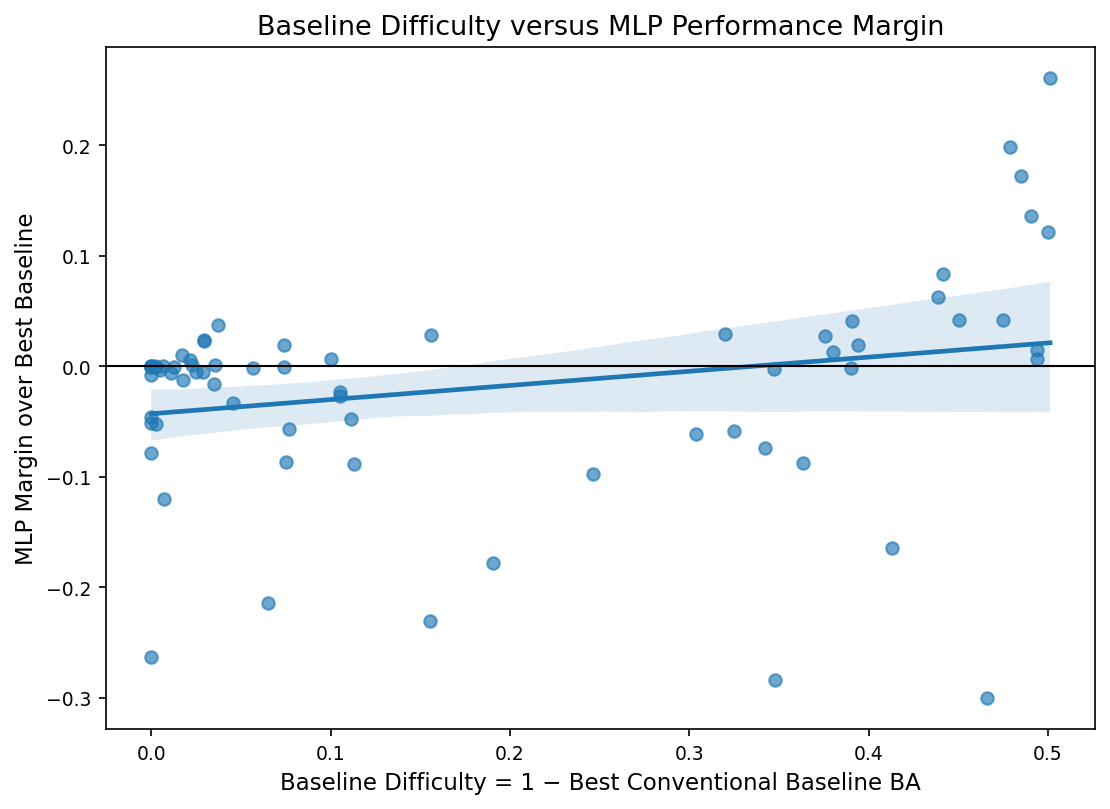

In [80]:
# Table 4.15 / Figure 4.21 — Secondary continuous RQ2 robustness analysis
rq2_cont = df[["Baseline_Difficulty", "MLP_vs_Best"]].dropna()

pearson_r, pearson_p = stats.pearsonr(rq2_cont["Baseline_Difficulty"], rq2_cont["MLP_vs_Best"])
spearman_rho, spearman_p = stats.spearmanr(rq2_cont["Baseline_Difficulty"], rq2_cont["MLP_vs_Best"])

rq2_cont_table = pd.DataFrame([
    {"Method": "Pearson", "Coefficient": pearson_r, "p-value": pearson_p},
    {"Method": "Spearman", "Coefficient": spearman_rho, "p-value": spearman_p},
])

rq2_cont_table.to_csv("tables/Table_4_15_RQ2_Continuous_Difficulty_Robustness.csv", index=False)

print(" Secondary Continuous-Difficulty Robustness Analysis")
print(tabulate(rq2_cont_table.round(6), headers="keys", tablefmt="github", showindex=False))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.regplot(
    data=df,
    x="Baseline_Difficulty",
    y="MLP_vs_Best",
    ax=ax,
    scatter_kws={"alpha": 0.65},
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Baseline Difficulty versus MLP Performance Margin")
ax.set_xlabel("Baseline Difficulty = 1 − Best Conventional Baseline BA")
ax.set_ylabel("MLP Margin over Best Baseline")
plt.tight_layout()
plt.savefig("figures/Fig4_21_RQ2_Continuous_Difficulty.png")
plt.show()

## 4.7 MLP Hyperparameter Analysis

This section describes which MLP configurations were selected most frequently after the systematic search. It is supplementary to RQ1–RQ3 and should not be interpreted as proving that any hyperparameter value is universally optimal.

In [81]:
def parse_hp(hp_str):
    result = {}
    if pd.isna(hp_str):
        return result
    for item in str(hp_str).split(","):
        parts = item.strip().split("=")
        if len(parts) == 2:
            result[parts[0].strip()] = parts[1].strip()
    return result

# Preserve the experimental Top and Bottom MLP configuration outputs
top_hp = df_top.copy()
if "Dataset_Type" not in top_hp.columns:
    top_hp["Dataset_Type"] = "top"

bottom_hp = df_bot.copy()
bottom_hp["Dataset_Type"] = "bottom"

hp_all = pd.concat(
    [
        top_hp[["Datasets", "Hyperparameters", "Dataset_Type"]],
        bottom_hp[["Datasets", "Hyperparameters", "Dataset_Type"]],
    ],
    ignore_index=True,
)

hp_parsed = hp_all["Hyperparameters"].apply(parse_hp).apply(pd.Series)
hp_all = pd.concat([hp_all.reset_index(drop=True), hp_parsed], axis=1)

print("Best-configuration hyperparameter frequencies:")
for col in [
    "Hidden_Neurons",
    "Activation_Function",
    "Learning_Rate",
    "Batch_Size",
    "Epochs",
]:
    if col in hp_all.columns:
        print(f"\n{col}:")
        print(hp_all[col].value_counts(dropna=False).to_string())

if "Learning_Rate" in hp_all.columns:
    lr_numeric = pd.to_numeric(hp_all["Learning_Rate"], errors="coerce")
    if lr_numeric.notna().any() and np.isclose(lr_numeric.max(), 0.01):
        count_upper = np.isclose(lr_numeric, 0.01).sum()
        print(f"\nSearch-boundary note: learning rate 0.01 (upper tested value) "
              f"was selected in {count_upper} best configurations.")

Best-configuration hyperparameter frequencies:

Hidden_Neurons:
Hidden_Neurons
128    25
64     17
32     12
8       7
16      7
NaN     1

Activation_Function:
Activation_Function
ReLU       31
Tanh       24
Sigmoid    13
NaN         1

Learning_Rate:
Learning_Rate
0.01       56
0.001       8
0.0001      3
NaN         1
0.00025     1

Batch_Size:
Batch_Size
8      28
16     18
64      8
32      7
128     7
NaN     1

Epochs:
Epochs
50     65
100     2
NaN     1
300     1

Search-boundary note: learning rate 0.01 (upper tested value) was selected in 56 best configurations.


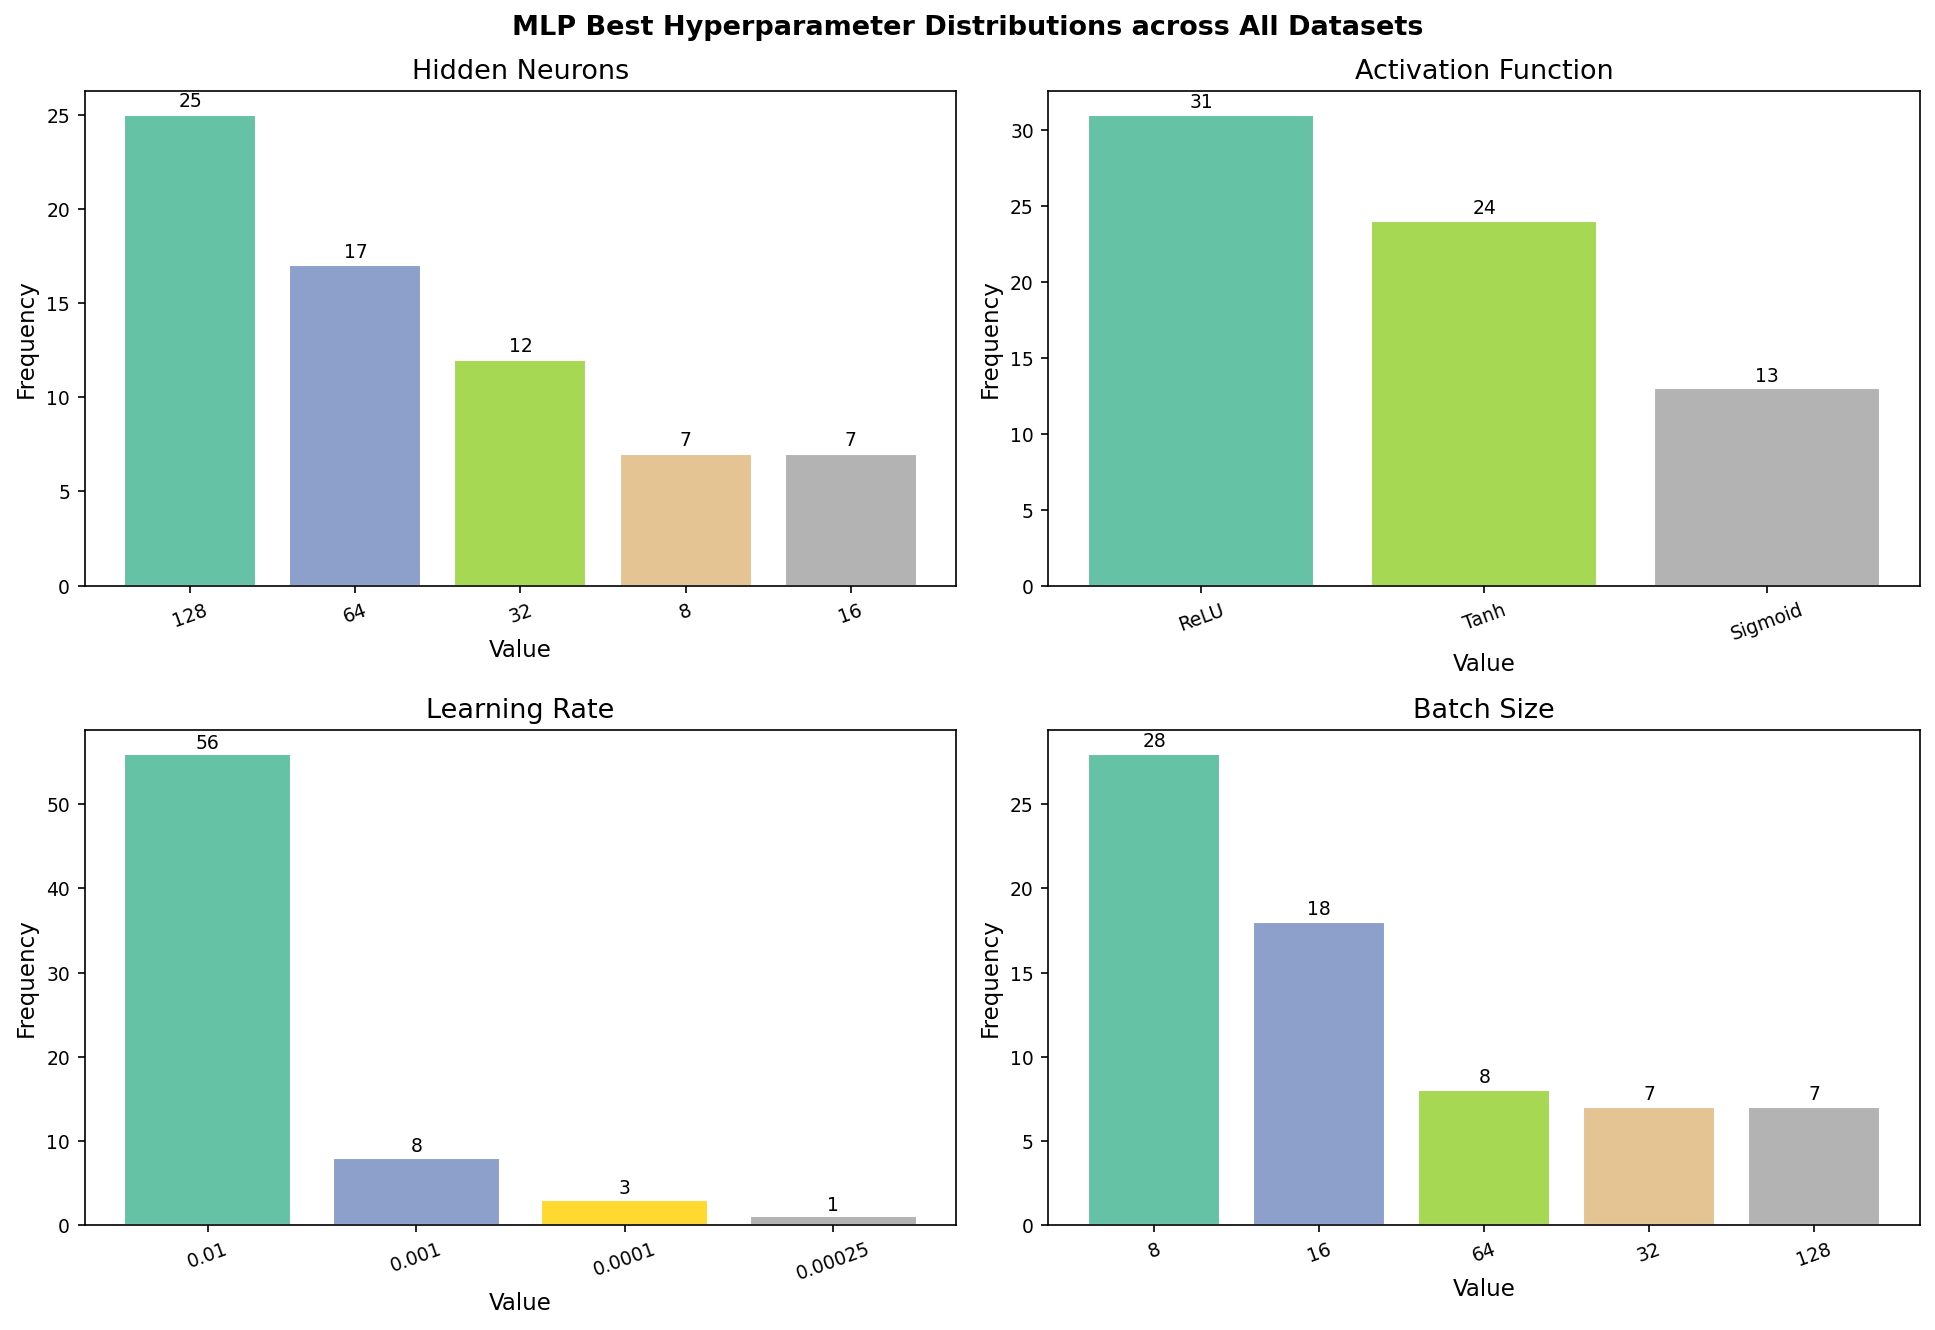

In [82]:
# ── Figure 4.22 — Hyperparameter distributions ───────────────────────────────
hp_cats = ["Hidden_Neurons","Activation_Function","Learning_Rate","Batch_Size"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for ax, col in zip(axes, hp_cats):
    if col not in hp_all.columns: ax.set_visible(False); continue
    vc = hp_all[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values,
           color=plt.cm.Set2(np.linspace(0, 1, len(vc))), edgecolor="white")
    ax.set_title(col.replace("_"," ")); ax.set_xlabel("Value"); ax.set_ylabel("Frequency")
    for bar, v in zip(ax.patches, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                str(v), ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("MLP Best Hyperparameter Distributions across All Datasets",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Fig4_22_Hyperparameters.png"); plt.show()

In [41]:
# ── Hyperparameter by group cross-tabs ───────────────────────────────────────
for col in ["Hidden_Neurons","Activation_Function","Learning_Rate","Batch_Size"]:
    if col not in hp_all.columns: continue
    print(f"\n── {col} by Dataset_Type ──")
    ct = pd.crosstab(hp_all["Dataset_Type"], hp_all[col])
    print(tabulate(ct, headers="keys", tablefmt="github"))


── Hidden_Neurons by Dataset_Type ──
| Dataset_Type   |   128 |   16 |   32 |   64 |   8 |
|----------------|-------|------|------|------|-----|
| bottom         |     7 |    5 |    6 |    7 |   3 |
| top            |    18 |    2 |    6 |   10 |   4 |

── Activation_Function by Dataset_Type ──
| Dataset_Type   |   ReLU |   Sigmoid |   Tanh |
|----------------|--------|-----------|--------|
| bottom         |      9 |         3 |     16 |
| top            |     22 |        10 |      8 |

── Learning_Rate by Dataset_Type ──
| Dataset_Type   |   0.0001 |   0.00025 |   0.001 |   0.01 |
|----------------|----------|-----------|---------|--------|
| bottom         |        2 |         1 |       3 |     22 |
| top            |        1 |         0 |       5 |     34 |

── Batch_Size by Dataset_Type ──
| Dataset_Type   |   128 |   16 |   32 |   64 |   8 |
|----------------|-------|------|------|------|-----|
| bottom         |     5 |    7 |    5 |    2 |   9 |
| top            |     2 |   1

## Section 4.8: Export — Publication-Ready Tables

In [42]:
# Export authoritative master results table
export_cols = [
    "Datasets", "Dataset_Type",
    "MLP_BA", "RF_BA", "XGB_BA", "LR_BA",
    "Rows", "Features", "Classes", "Imbalance",
    "Best_Baseline", "Baseline_Difficulty", "MLP_vs_Best", "MLP_Rank",
]
export_cols = [c for c in export_cols if c in df.columns]

export_df = df[export_cols].copy()
export_df = export_df.sort_values(["Dataset_Type", "MLP_BA"], ascending=[True, False])

export_df.to_csv("tables/Table_4_Master_Results.csv", index=False)
export_df.to_excel("tables/Table_4_Master_Results.xlsx", index=False)

latex_str = export_df.round(4).to_latex(
    index=False,
    caption="Full Model Performance Results on the Selected PMLB Classification Datasets",
    label="tab:full_results",
    longtable=True,
    escape=True,
)
with open("tables/Table_4_Master_Results.tex", "w") as f:
    f.write(latex_str)

print("Exported authoritative master results as CSV, Excel and LaTeX.")

Exported authoritative master results as CSV, Excel and LaTeX.


In [43]:
# Save a reproducibility/analysis manifest for Chapter 4
analysis_manifest = {
    "primary_metric": "Balanced Accuracy",
    "principal_sample_size": int(len(df_complete)),
    "models": [MODEL_LABELS[m] for m in MODELS],
    "rq2_primary_difficulty_definition": "Preselected Bottom datasets derived from poor baseline-model performance",
    "rq2_secondary_robustness_definition": "1 - max(LR_BA, RF_BA, XGB_BA)",
    "mlp_competitiveness": "MLP_BA - max(LR_BA, RF_BA, XGB_BA)",
    "omnibus_test": "Friedman",
    "posthoc_test": "Nemenyi, conditional on valid significant Friedman result",
    "planned_pairwise_test": "Wilcoxon signed-rank",
    "multiple_testing_correction": "Holm",
    "rq3_primary_target": "MLP_vs_Best",
    "meta_model": "RandomForestRegressor with RepeatedKFold validation and held-out permutation importance",
}

with open("tables/Chapter4_Analysis_Manifest.json", "w") as f:
    json.dump(analysis_manifest, f, indent=2)

print(json.dumps(analysis_manifest, indent=2))

{
  "primary_metric": "Balanced Accuracy",
  "principal_sample_size": 69,
  "models": [
    "MLP",
    "Random Forest",
    "XGBoost",
    "Logistic Regression"
  ],
  "rq2_primary_difficulty_definition": "Preselected Bottom datasets derived from poor baseline-model performance",
  "rq2_secondary_robustness_definition": "1 - max(LR_BA, RF_BA, XGB_BA)",
  "mlp_competitiveness": "MLP_BA - max(LR_BA, RF_BA, XGB_BA)",
  "omnibus_test": "Friedman",
  "posthoc_test": "Nemenyi, conditional on valid significant Friedman result",
  "planned_pairwise_test": "Wilcoxon signed-rank",
  "multiple_testing_correction": "Holm",
  "rq3_primary_target": "MLP_vs_Best",
  "meta_model": "RandomForestRegressor with RepeatedKFold validation and held-out permutation importance"
}


In [44]:
# ── Final inventory ────────────────────────────────────────────────────────────
import glob
figs = sorted(glob.glob("figures/*.png"))
tabs = sorted(glob.glob("tables/*.csv") + glob.glob("tables/*.xlsx") + glob.glob("tables/*.tex"))
print(f"{'='*55}")
print(f"  FIGURES GENERATED : {len(figs)}")
for f in figs: print(f"    {f}")
print(f"{'='*55}")
print(f"  TABLES GENERATED  : {len(tabs)}")
for t in tabs: print(f"    {t}")
print(f"{'='*55}")
print(f"  Datasets total    : {len(df)} (top={len(df_top_group)}, bottom={len(df_bot_group)})")
print(f"  Models compared   : 4 (MLP, RF, XGBoost, Logistic Regression)")

  FIGURES GENERATED : 21
    figures\Fig4_10_Performance_Heatmap.png
    figures\Fig4_11_MLP_Margin_Bottom.png
    figures\Fig4_12_Bottom_Datasets_Bar.png
    figures\Fig4_13_Top_Datasets_Bar.png
    figures\Fig4_14_Nemenyi_Heatmap.png
    figures\Fig4_15_Average_Rank_Diagram.png
    figures\Fig4_16_Dataset_Characteristics.png
    figures\Fig4_17_Characteristics_Boxplot.png
    figures\Fig4_18_Features_vs_MLP_Margin.png
    figures\Fig4_1_BA_Distributions.png
    figures\Fig4_20_Permutation_Importance.png
    figures\Fig4_21_RQ2_Continuous_Difficulty.png
    figures\Fig4_22_Hyperparameters.png
    figures\Fig4_2_Boxplots_All.png
    figures\Fig4_3_Violin_Plots.png
    figures\Fig4_4_Scatter_Matrix.png
    figures\Fig4_5_Correlation_Heatmap.png
    figures\Fig4_6_Rank_Distribution.png
    figures\Fig4_7_Win_Counts.png
    figures\Fig4_8_MeanBA_Grouped.png
    figures\Fig4_9_MLP_vs_Baselines_Scatter.png
  TABLES GENERATED  : 18
    tables\Table_4_10_RQ2_Bottom_Wilcoxon_Holm.csv
    table

## 4.9 Research-Question Summary and Examiner-Safe Reporting

The following cells produce concise numerical summaries for Chapter 4. They deliberately separate descriptive observations from inferential conclusions.

In [45]:
print("=" * 80)
print("RQ1 — Overall comparative performance")
print("=" * 80)

summary_rq1 = table_44.copy()
print(tabulate(summary_rq1.round(4), headers="keys", tablefmt="github", showindex=False))

print("\nFriedman:")
print(f"chi2({k_models-1}) = {friedman_stat:.4f}, "
      f"p = {'<0.001' if friedman_p < 0.001 else f'{friedman_p:.6f}'}, "
      f"Kendall W = {kendalls_w:.4f}")

print("\nPlanned Holm-adjusted MLP comparisons:")
for _, row in pairwise_df.iterrows():
    ptxt = "<0.001" if row["Holm-adjusted p-value"] < 0.001 else f"{row['Holm-adjusted p-value']:.6f}"
    print(
        f"{row['Comparison']}: wins={row['MLP wins']}, losses={row['MLP losses']}, ties={row['Ties']}, "
        f"adjusted p={ptxt}, median difference={row['Median BA difference']:.4f}, "
        f"rank-biserial={row['Rank-biserial effect']:.4f}"
    )

print("\nReporting rule: no non-significant comparison is to be described as statistical equivalence.")

RQ1 — Overall comparative performance
| Model               |   Mean BA |   Std Dev |   Median BA |   Joint first-place count |   Joint first-place rate (%) |   Average Rank |
|---------------------|-----------|-----------|-------------|---------------------------|------------------------------|----------------|
| MLP                 |    0.799  |    0.1894 |      0.868  |                        28 |                      40.5797 |         1.913  |
| Random Forest       |    0.7986 |    0.2002 |      0.8973 |                        29 |                      42.029  |         2.029  |
| Logistic Regression |    0.7543 |    0.1814 |      0.7814 |                        13 |                      18.8406 |         2.6014 |
| XGBoost             |    0.6611 |    0.17   |      0.5759 |                         5 |                       7.2464 |         3.4565 |

Friedman:
chi2(3) = 62.5683, p = <0.001, Kendall W = 0.3023

Planned Holm-adjusted MLP comparisons:
MLP vs Random Forest: wins=35, lo

### RQ2 — MLP Performance on Difficult (Bottom) Datasets

In [46]:
print("=" * 80)
print("RQ2 — MLP performance on Bottom (difficult) datasets")
print("=" * 80)

bottom_model_summary = pd.DataFrame([
    {
        "Model": MODEL_LABELS[m],
        "Mean BA": df_bot_group[m].mean(),
        "Median BA": df_bot_group[m].median(),
        "Std Dev": df_bot_group[m].std(ddof=1),
    }
    for m in MODELS
]).sort_values("Mean BA", ascending=False)

print(tabulate(bottom_model_summary.round(4), headers="keys", tablefmt="github", showindex=False))

print("\nMLP relative to strongest baseline:")
print(f"Bottom datasets: {len(df_bot_group)}")
print(f"MLP > best baseline: {(df_bot_group['MLP_vs_Best'] > 0).sum()}")
print(f"MLP = best baseline: {(df_bot_group['MLP_vs_Best'] == 0).sum()}")
print(f"MLP < best baseline: {(df_bot_group['MLP_vs_Best'] < 0).sum()}")
print(f"Mean MLP margin: {df_bot_group['MLP_vs_Best'].mean():.4f}")
print(f"Median MLP margin: {df_bot_group['MLP_vs_Best'].median():.4f}")

print("\nHolm-adjusted Bottom-group comparisons:")
for _, row in bottom_pairwise.iterrows():
    ptxt = "<0.001" if row["Holm-adjusted p-value"] < 0.001 else f"{row['Holm-adjusted p-value']:.6f}"
    print(
        f"{row['Comparison']}: wins={row['MLP wins']}, losses={row['MLP losses']}, "
        f"adjusted p={ptxt}, median difference={row['Median BA difference']:.4f}"
    )

print("\nSecondary continuous robustness:")
print(rq2_cont_table.round(6).to_string(index=False))
print("\nPrimary RQ2 inference must be based on the predefined Bottom group; "
      "the continuous analysis is corroborative only.")

RQ2 — MLP performance on Bottom (difficult) datasets
| Model               |   Mean BA |   Median BA |   Std Dev |
|---------------------|-----------|-------------|-----------|
| MLP                 |    0.5975 |      0.6246 |    0.1084 |
| Logistic Regression |    0.5712 |      0.5492 |    0.0891 |
| Random Forest       |    0.569  |      0.5543 |    0.075  |
| XGBoost             |    0.519  |      0.5163 |    0.0264 |

MLP relative to strongest baseline:
Bottom datasets: 28
MLP > best baseline: 16
MLP = best baseline: 0
MLP < best baseline: 12
Mean MLP margin: -0.0096
Median MLP margin: 0.0139

Holm-adjusted Bottom-group comparisons:
MLP vs Random Forest: wins=20, losses=8, adjusted p=0.218503, median difference=0.0447
MLP vs XGBoost: wins=25, losses=3, adjusted p=0.003868, median difference=0.1003
MLP vs Logistic Regression: wins=20, losses=8, adjusted p=0.218503, median difference=0.0413

Secondary continuous robustness:
  Method  Coefficient  p-value
 Pearson     0.247661 0.04019

### RQ3 — Dataset Meta-Features and Relative MLP Competitiveness

In [47]:
print("=" * 80)
print("RQ3 — Dataset meta-feature associations with MLP competitiveness")
print("=" * 80)

print("\nCorrelation analysis target: MLP_vs_Best (not absolute MLP_BA)")
print(tabulate(corr_tbl.round(6), headers="keys", tablefmt="github", showindex=False))

print("\nExploratory meta-model validation:")
print(tabulate(cv_table.round(4), headers="keys", tablefmt="github", showindex=False))

print("\nHeld-out permutation importance:")
print(tabulate(perm_summary.round(6), headers="keys", tablefmt="github", showindex=False))

print("\nReporting rule: weak or unstable out-of-sample meta-model performance means "
      "feature-importance values are exploratory only and must not be called statistically significant determinants.")

RQ3 — Dataset meta-feature associations with MLP competitiveness

Correlation analysis target: MLP_vs_Best (not absolute MLP_BA)
| Feature          |   N |   Pearson r |   Pearson raw p |   Spearman rho |   Spearman raw p |   Pearson Holm p |   Spearman Holm p | Pearson significant   | Spearman significant   |   Absolute Spearman rho |
|------------------|-----|-------------|-----------------|----------------|------------------|------------------|-------------------|-----------------------|------------------------|-------------------------|
| Classes          |  69 |   -0.247342 |        0.040462 |      -0.410512 |         0.000459 |         0.242774 |          0.002756 | False                 | True                   |                0.410512 |
| Feat_Row_Ratio   |  69 |   -0.088237 |        0.470927 |      -0.198525 |         0.101993 |         1        |          0.509963 | False                 | False                  |                0.198525 |
| Rows             |  69 |    0.106

---

## Final Chapter 4 Reporting Checklist

Before transferring results into the dissertation:

- Use **only values generated by this notebook** as the final Chapter 4 numerical results.
- Report the **69 selected PMLB classification datasets**, not the entire PMLB repository.
- Use **joint first-place** terminology when ties cause counts to exceed the number of datasets.
- For RQ1, report Friedman first; interpret Nemenyi only because the valid omnibus result permits it.
- Report both raw and **Holm-adjusted** p-values for the planned Wilcoxon comparisons.
- Describe MLP versus Random Forest as **“no statistically significant difference detected”** if the adjusted result remains non-significant; do not call the models equivalent.
- For RQ2, treat the predefined **Bottom datasets as the primary difficult-dataset group**.
- Describe Bottom datasets as difficult **for the selected baseline models under the implemented protocol**, not intrinsically difficult.
- Treat continuous baseline difficulty as a **secondary robustness check**.
- For RQ3, use **MLP_vs_Best / MLP performance margin** as the primary response variable.
- Exclude constant and exact duplicate meta-features from inferential/meta-model analysis.
- Interpret feature importance only in light of out-of-sample meta-model performance.
- Keep the hyperparameter analysis supplementary; it describes selected configurations but does not establish universal optimality.